In [1]:
import os
from glob import glob

# Base path
TRAIN_DIR = "/kaggle/input/datasets/panda2206/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"

# List all class folders (c0, c1, ..., c9)
class_dirs = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", class_dirs)
# Collect all image paths
train_images = []
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = glob(os.path.join(cls_path, "*.jpg"))
    train_images.extend(images)

print(f"Total training images: {len(train_images)}")
# print("Sample image paths:")
# train_images[:5]
# # o /kaggle/temp/, but they won't be saved outside of the current session

Classes found: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Total training images: 22424


In [ ]:
# import os

# CACHE = "/kaggle/temp/hf_cache"
# MODELS = "/kaggle/temp/hf_models"

# os.environ["HF_HOME"] = CACHE
# os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE
# os.environ["TRANSFORMERS_CACHE"] = CACHE
# os.environ["DIFFUSERS_CACHE"] = CACHE
# os.environ["TORCH_HOME"] = "/kaggle/temp/torch_cache"
# os.environ["HF_HUB_DISABLE_XET"] = "1"

# os.makedirs(CACHE, exist_ok=True)
# os.makedirs(MODELS, exist_ok=True)


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

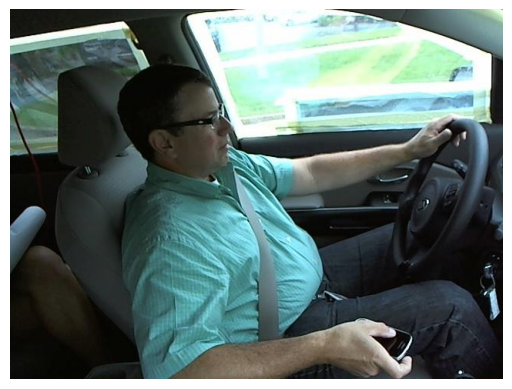

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(train_images[0])
plt.imshow(img)
plt.axis("off")

In [3]:
!git clone https://github.com/hqhQAQ/PatchDPO.git
%cd PatchDPO
# Install core deps (Kaggle already has torch; we mainly need diffusers/accelerate/transformers etc.)
# !pip -q install -U "diffusers==0.23.1" "transformers==4.35.2" "accelerate==0.23.0" safetensors einops opencv-python Pillow tqdm


Cloning into 'PatchDPO'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (237/237), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 237 (delta 116), reused 223 (delta 109), pack-reused 0 (from 0)
Receiving objects: 100% (237/237), 23.11 MiB | 25.42 MiB/s, done.
Resolving deltas: 100% (116/116), done.
/kaggle/working/PatchDPO


In [4]:
import os

os.environ["HF_HOME"] = "/kaggle/temp/hf_cache"
os.environ["HUGGINGFACE_HUB_CACHE"] = "/kaggle/temp/hf_cache"
os.environ["HF_HUB_DISABLE_XET"] = "1"

os.makedirs("/kaggle/temp/hf_models", exist_ok=True)

In [5]:
from huggingface_hub import snapshot_download
# import os
# os.environ["HF_HOME"] = "/kaggle/working/hf_cache"
# os.environ["HUGGINGFACE_HUB_CACHE"] = "/kaggle/working/hf_cache"
# os.makedirs("/kaggle/working/hf_models", exist_ok=True)

# 1) Base SDXL model (RealVisXL)
base_model_dir = snapshot_download(
    repo_id="SG161222/RealVisXL_V1.0",
    local_dir="/kaggle/temp/working/hf_models/RealVisXL_V1.0",
    local_dir_use_symlinks=False
)

# 2) IP-Adapter repo (contains image_encoder + ip-adapter weights)
ip_adapter_dir = snapshot_download(
    repo_id="h94/IP-Adapter",
    local_dir="/kaggle/temp/working/hf_models/IP-Adapter",
    local_dir_use_symlinks=False
)

# 3) PatchDPO weights repo (contains model.bin per README)
patchdpo_dir = snapshot_download(
    repo_id="hqhQAQ/PatchDPO",
    local_dir="/kaggle/temp/working/hf_models/PatchDPO",
    local_dir_use_symlinks=False
)

print("IP-Adapter:", ip_adapter_dir)
print("PatchDPO:", patchdpo_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 25 files:   0%|          | 0/25 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

...

model.bin:   0%|          | 0.00/848M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

IP-Adapter: /kaggle/temp/working/hf_models/IP-Adapter
PatchDPO: /kaggle/temp/working/hf_models/PatchDPO


In [6]:
!pip -q install \
  diffusers \
  transformers \
  accelerate \
  safetensors \
  sentencepiece

In [7]:
from diffusers import StableDiffusionXLPipeline
print("StableDiffusionXLPipeline import OK ✅")

2026-03-05 17:00:30.273850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772730030.475978      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772730030.532046      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772730031.039764      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772730031.039813      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772730031.039816      55 computation_placer.cc:177] computation placer alr

StableDiffusionXLPipeline import OK ✅


In [ ]:
# import os, torch
# from diffusers import StableDiffusionXLPipeline

# BASE_DIR = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
# # BASE_DIR = "/kaggle/temp/hf_models/RealVisXL_V1.0"
# OUT_DIR  = "/kaggle/working/synth"
# os.makedirs(OUT_DIR, exist_ok=True)

# pipe = StableDiffusionXLPipeline.from_pretrained(
#     BASE_DIR,
#     torch_dtype=torch.float16,
#     variant="fp16",
#     use_safetensors=True,
# ).to("cuda")

# pipe.enable_vae_slicing()
# pipe.enable_attention_slicing("auto")

# generator = torch.Generator("cuda").manual_seed(42)

# prompts = {
#   "c0": "photo inside a moving car, driver holding the steering wheel with both hands, eyes open, focused on the road, daytime lighting",
#   "c1": "inside car photo of a distracted driver texting on a smartphone with their right hand, eyes open, casual clothing, realistic interior",
#   "c2": "photo inside a car of a driver talking on a phone with the right hand near their ear while steering, eyes open, natural lighting",
#   "c3": "inside car photo of a driver texting with their left hand while the other hand is on the steering wheel, eyes open, realistic style",
#   "c4": "driver talking on a phone with the left hand, sitting in the driver seat of a regular sedan, eyes open, natural daylight",
#   "c5": "driver reaching toward the car radio or central console, adjusting controls, eyes open, interior photo",
#   "c6": "driver taking a sip from a water bottle or travel cup while driving, eyes open, realistic car interior photo",
#   "c7": "driver reaching behind the seat to grab an item, torso twisted, eyes open, car interior photo",
#   "c8": "driver applying makeup with a compact mirror while seated behind the wheel, eyes open, realistic lighting",
#   "c9": "driver looking and talking to a passenger on the right side, expressive gesture, eyes open, realistic interior photo"
# }

# for k, prompt in prompts.items():
#     with torch.no_grad():
#         img = pipe(
#             prompt=prompt,
#             negative_prompt="blurry, low quality, bad hands, deformed, extra fingers, watermark, text",
#             num_inference_steps=30,
#             guidance_scale=5.5,
#             height=768,   # safer than 1024
#             width=768,
#             generator=generator
#         ).images[0]

#     img.save(f"{OUT_DIR}/{k}.png")

# print("Saved to:", OUT_DIR)

# stable diffusion and load apater

In [ ]:
import os, random, torch, csv, shutil
from glob import glob
from PIL import Image
from diffusers import StableDiffusionXLPipeline

BASE_DIR  = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
IP_DIR    = "/kaggle/temp/working/hf_models/IP-Adapter"
TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
OUT_DIR   = "/kaggle/working/synth_ipadapter"
os.makedirs(OUT_DIR, exist_ok=True)

META_CSV  = os.path.join(OUT_DIR, "meta.csv")

# ---------------- LOAD PIPE ----------------
device = "cuda"

pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
).to(device)

# Important for IP-Adapter
pipe.disable_attention_slicing()
pipe.enable_vae_slicing()

pipe.load_ip_adapter(
    IP_DIR,
    subfolder="sdxl_models",
    weight_name="ip-adapter_sdxl.safetensors"
)
pipe.set_ip_adapter_scale(0.7)


negative_prompt =  "blurry, low resolution, distorted hands, extra limbs, deformed face, watermark, cartoon, CGI, text overlay, outdoor scene, view of street, road, highway, exterior shot, outside of car"


prompts = {
  "c0": "photo inside a moving car, driver holding the steering wheel with both hands, eyes open, focused on the road, daytime lighting",
  "c1": "inside car photo of a distracted driver texting on a smartphone with their right hand, eyes open, casual clothing, realistic interior",
  "c2": "photo inside a car of a driver talking on a phone with the right hand near their ear while steering, eyes open, natural lighting",
  "c3": "inside car photo of a driver texting with their left hand while the other hand is on the steering wheel, eyes open, realistic style",
  "c4": "driver talking on a phone with the left hand, sitting in the driver seat of a regular sedan, eyes open, natural daylight",
}

# ---------------- SETTINGS ----------------
IMAGES_PER_CLASS = 5
HEIGHT = 640
WIDTH  = 640
STEPS  = 20
GUIDANCE = 5.5
BASE_SEED = 42

rows = []

# ---------------- GENERATION ----------------
for cls, prompt in prompts.items():
    cls_out = os.path.join(OUT_DIR, cls)
    os.makedirs(cls_out, exist_ok=True)

    real_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    if len(real_paths) == 0:
        print(f"[WARN] No real images found for {cls}, skipping.")
        continue

    for j in range(IMAGES_PER_CLASS):
        ref_path = random.choice(real_paths)
        ref_img = Image.open(ref_path).convert("RGB")

        # unique seed per (class, image)
        seed = BASE_SEED + int(cls[1:]) * 1000 + j * 111
        generator = torch.Generator(device).manual_seed(seed)

        out_path = os.path.join(cls_out, f"{cls}_{j}.png")
        print(f"{cls} image {j+1}/{IMAGES_PER_CLASS} | seed={seed}")

        with torch.no_grad():
            img = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                ip_adapter_image=ref_img,
                num_inference_steps=STEPS,
                guidance_scale=GUIDANCE,
                height=HEIGHT,
                width=WIDTH,
                generator=generator,
            ).images[0]

        img.save(out_path)

        rows.append({
            "class": cls,
            "gen_path": out_path,
            "ref_path": ref_path,
            "prompt": prompt,
            "seed": seed
        })

# ---------------- SAVE META CSV ----------------
with open(META_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class","gen_path","ref_path","prompt","seed"])
    writer.writeheader()
    writer.writerows(rows)

print("Generation complete.")
print("Saved to:", OUT_DIR)
print("Meta CSV:", META_CSV)

# ---------------- ZIP FOR DOWNLOAD ----------------
zip_base = OUT_DIR  # zip will be OUT_DIR + ".zip"
zip_path = shutil.make_archive(zip_base, "zip", OUT_DIR)
print("ZIP saved at:", zip_path)

In [ ]:
# import os, random, torch
# from glob import glob
# from PIL import Image
# from diffusers import StableDiffusionXLPipeline

# BASE_DIR  = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
# IP_DIR    = "/kaggle/temp/working/hf_models/IP-Adapter"
# TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
# OUT_DIR   = "/kaggle/working/synth_ipadapter"
# os.makedirs(OUT_DIR, exist_ok=True)

# # ---- Fresh pipeline ----
# pipe = StableDiffusionXLPipeline.from_pretrained(
#     BASE_DIR,
#     torch_dtype=torch.float16,
#     variant="fp16",
#     use_safetensors=True,
# ).to("cuda")

# # ✅ make sure slicing is OFF before IP-Adapter
# pipe.disable_attention_slicing()

# # (vae slicing is OK)
# pipe.enable_vae_slicing()

# # ✅ load SDXL ip-adapter weights that match your encoder
# pipe.load_ip_adapter(
#     IP_DIR,
#     subfolder="sdxl_models",
#     weight_name="ip-adapter_sdxl.safetensors"
# )

# pipe.set_ip_adapter_scale(0.7)

# generator = torch.Generator("cuda").manual_seed(42)

# negative_prompt = (
# "blurry, low resolution, distorted hands, extra limbs, deformed face, watermark, cartoon,anime, CGI, text overlay, outdoor scene,"
# " view of street, road, highway, exterior shot, outside of car")

# prompts = {
#   "c0": "photo inside a moving car, driver holding the steering wheel with both hands, eyes open, focused on the road, daytime lighting",
#   "c1": "inside car photo of a distracted driver texting on a smartphone with their right hand, eyes open, casual clothing, realistic interior",
#   "c2": "photo inside a car of a driver talking on a phone with the right hand near their ear while steering, eyes open, natural lighting",
#   "c3": "inside car photo of a driver texting with their left hand while the other hand is on the steering wheel, eyes open, realistic style",
#   "c4": "driver talking on a phone with the left hand, sitting in the driver seat of a regular sedan, eyes open, natural daylight",
# }




# ref_path = random.choice(glob(os.path.join(TRAIN_DIR, "c0", "*.jpg")))
# ref_img = Image.open(ref_path).convert("RGB")
# print("Reference:", ref_path)

# for k, prompt in prompts.items():
#     with torch.no_grad():
#         img = pipe(
#             prompt=prompt,
#             negative_prompt=negative_prompt,
#             ip_adapter_image=ref_img,
#             num_inference_steps=20,
#             guidance_scale=5.5,
#             height=640,
#             width=640,
#             generator=generator
#         ).images[0]
#     img.save(f"{OUT_DIR}/{k}_ref.png")

# print("Saved to:", OUT_DIR)

# patchdpo, sdxl and  load adpater with prompt template 1


In [ ]:
import os, random, torch, csv, shutil
from glob import glob
from PIL import Image
from diffusers import StableDiffusionXLPipeline

# IMPORTANT: use PatchDPO repo version
import sys
sys.path.insert(0, "/kaggle/working/PatchDPO")
from ip_adapter.ip_adapter import IPAdapterPlusXL

# ---------------- PATHS ----------------
BASE_DIR = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
IP_DIR   = "/kaggle/temp/working/hf_models/IP-Adapter"
PATCHDPO_DIR = "/kaggle/temp/working/hf_models/PatchDPO"

IMAGE_ENCODER_PATH = f"{IP_DIR}/models/image_encoder"
STATE_DICT_PATH    = f"{IP_DIR}/sdxl_models/ip-adapter-plus_sdxl_vit-h.bin"
PATCHDPO_CKPT      = f"{PATCHDPO_DIR}/model.bin"

TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
OUT_DIR   = "/kaggle/working/patchdpo_output"
os.makedirs(OUT_DIR, exist_ok=True)

META_CSV = os.path.join(OUT_DIR, "meta.csv")

# ---------------- LOAD MODEL ----------------
device="cuda"

pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to(device)

pipe.enable_vae_slicing()
pipe.disable_attention_slicing()

state_dict = torch.load(STATE_DICT_PATH, map_location="cpu")

ip_model = IPAdapterPlusXL(
    pipe,
    IMAGE_ENCODER_PATH,
    state_dict,
    PATCHDPO_CKPT,
    device,
    num_tokens=16
)

# ---------------- PROMPTS ----------------
prompts ={
    "c0": (
        "both hands on the steering wheel, eyes on the road, safe driving, "
        "side view of a driver inside a car, photographed from the front passenger seat angle, "
        "natural daylight, high-resolution realistic DSLR photo"
    ),
    "c1": (
        "driver texting on a phone with the right hand while driving, distracted driving, "
        "side view of a driver inside a car, camera at the front passenger seat, "
        "realistic car interior photo"
    ),
    "c2": ( "driver talking on a phone with the right hand near the ear while driving, "
        "side view of a driver inside a car, camera from passenger seat, "
        "distracted driving, realistic DSLR photo"
    ),
    "c3": ("driver texting on a phone with the left hand while driving, "
        "side view of a driver inside a car, photographed from passenger seat, "
        "distracted driving, realistic car interior"
    ),
    "c4": (  "driver talking on a phone with the left hand near the ear while driving, "
        "side view of a driver inside a car, passenger-seat camera angle, "
        "distracted driving, realistic photo"
    ),
}
negative_prompt =  "blurry, low resolution, distorted hands, extra limbs, deformed face, watermark, cartoon, CGI, text overlay, outdoor scene, view of street, road, highway, exterior shot, outside of car"


# ---------------- SETTINGS ----------------
IMAGES_PER_CLASS = 5   # ✅ now 5 images per class
HEIGHT = 720
WIDTH  = 720
STEPS  = 30
SCALE  = 0.65
GUIDANCE = 5.5
BASE_SEED = 42

rows = []

# ---------------- GENERATION ----------------
for cls, prompt in prompts.items():
    cls_out = os.path.join(OUT_DIR, cls)
    os.makedirs(cls_out, exist_ok=True)

    real_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    if len(real_paths) == 0:
        continue

    for j in range(IMAGES_PER_CLASS):
        ref_path = random.choice(real_paths)
        ref_img  = Image.open(ref_path).convert("RGB")

        seed = BASE_SEED + int(cls[1:]) + j*100
        out_path = os.path.join(cls_out, f"{cls}_{j}.png")

        print(f"{cls} image {j+1}/5")

        images = ip_model.generate(
            pil_image=ref_img,
            prompt=prompt,
            negative_prompt=negative_prompt,
            scale=SCALE,
            num_samples=1,
            num_inference_steps=STEPS,
            seed=seed,
            guidance_scale=GUIDANCE,
            height=HEIGHT,
            width=WIDTH,
        )

        images[0].save(out_path)

        rows.append({
            "class": cls,
            "gen_path": out_path,
            "ref_path": ref_path,
            "prompt": prompt,
            "seed": seed
        })

# ---------------- SAVE META CSV ----------------
with open(META_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class","gen_path","ref_path","prompt","seed"])
    writer.writeheader()
    writer.writerows(rows)

print("Generation complete")

# ---------------- ZIP FOR DOWNLOAD ----------------
zip_path = "/kaggle/working/patchdpo_output.zip"
shutil.make_archive("/kaggle/working/patchdpo_output", 'zip', OUT_DIR)

print("ZIP saved at:", zip_path)


# patchdpo with prompt template 2

In [ ]:
import os, random, torch, csv, shutil
from glob import glob
from PIL import Image
from diffusers import StableDiffusionXLPipeline

# IMPORTANT: use PatchDPO repo version
import sys
sys.path.insert(0, "/kaggle/working/PatchDPO")
from ip_adapter.ip_adapter import IPAdapterPlusXL

# ---------------- PATHS ----------------
BASE_DIR = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
IP_DIR   = "/kaggle/temp/working/hf_models/IP-Adapter"
PATCHDPO_DIR = "/kaggle/temp/working/hf_models/PatchDPO"

IMAGE_ENCODER_PATH = f"{IP_DIR}/models/image_encoder"
STATE_DICT_PATH    = f"{IP_DIR}/sdxl_models/ip-adapter-plus_sdxl_vit-h.bin"
PATCHDPO_CKPT      = f"{PATCHDPO_DIR}/model.bin"

TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
OUT_DIR   = "/kaggle/working/patchdpo_output1"
os.makedirs(OUT_DIR, exist_ok=True)

META_CSV = os.path.join(OUT_DIR, "meta.csv")

# ---------------- LOAD MODEL ----------------
device="cuda"

pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to(device)

pipe.enable_vae_slicing()
pipe.disable_attention_slicing()

state_dict = torch.load(STATE_DICT_PATH, map_location="cpu")

ip_model = IPAdapterPlusXL(
    pipe,
    IMAGE_ENCODER_PATH,
    state_dict,
    PATCHDPO_CKPT,
    device,
    num_tokens=16
)

# ---------------- PROMPTS ----------------

negative_prompt =  "blurry, low resolution, distorted hands, extra limbs, deformed face, watermark, cartoon, CGI, text overlay, outdoor scene, view of street, road, highway, exterior shot, outside of car"


prompts = {
  "c0": "photo inside a moving car, driver holding the steering wheel with both hands, eyes open, focused on the road, daytime lighting",
  "c1": "inside car photo of a distracted driver texting on a smartphone with their right hand, eyes open, casual clothing, realistic interior",
  "c2": "photo inside a car of a driver talking on a phone with the right hand near their ear while steering, eyes open, natural lighting",
  "c3": "inside car photo of a driver texting with their left hand while the other hand is on the steering wheel, eyes open, realistic style",
  "c4": "driver talking on a phone with the left hand, sitting in the driver seat of a regular sedan, eyes open, natural daylight",
}


# ---------------- SETTINGS ----------------
IMAGES_PER_CLASS = 5   # ✅ now 5 images per class
HEIGHT = 720
WIDTH  = 720
STEPS  = 30
SCALE  = 0.65
GUIDANCE = 5.5
BASE_SEED = 42

rows = []

# ---------------- GENERATION ----------------
for cls, prompt in prompts.items():
    cls_out = os.path.join(OUT_DIR, cls)
    os.makedirs(cls_out, exist_ok=True)

    real_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    if len(real_paths) == 0:
        continue

    for j in range(IMAGES_PER_CLASS):
        ref_path = random.choice(real_paths)
        ref_img  = Image.open(ref_path).convert("RGB")

        seed = BASE_SEED + int(cls[1:]) + j*100
        out_path = os.path.join(cls_out, f"{cls}_{j}.png")

        print(f"{cls} image {j+1}/5")

        images = ip_model.generate(
            pil_image=ref_img,
            prompt=prompt,
            negative_prompt=negative_prompt,
            scale=SCALE,
            num_samples=1,
            num_inference_steps=STEPS,
            seed=seed,
            guidance_scale=GUIDANCE,
            height=HEIGHT,
            width=WIDTH,
        )

        images[0].save(out_path)

        rows.append({
            "class": cls,
            "gen_path": out_path,
            "ref_path": ref_path,
            "prompt": prompt,
            "seed": seed
        })

# ---------------- SAVE META CSV ----------------
with open(META_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class","gen_path","ref_path","prompt","seed"])
    writer.writeheader()
    writer.writerows(rows)

print("Generation complete")

# ---------------- ZIP FOR DOWNLOAD ----------------
zip_path = "/kaggle/working/patchdpo_output1.zip"
shutil.make_archive("/kaggle/working/patchdpo_output1", 'zip', OUT_DIR)

print("ZIP saved at:", zip_path)


# evaulation

In [ ]:
!pip -q install scikit-image
!pip -q install git+https://github.com/openai/CLIP.git


In [ ]:
# import os, csv
# import numpy as np
# from PIL import Image
# from skimage.metrics import structural_similarity as ssim

# GEN_DIR  = "/kaggle/working/patchdpo_output"
# META_CSV = os.path.join(GEN_DIR, "meta.csv")

# assert os.path.exists(META_CSV), f"meta.csv not found: {META_CSV}"

# def load_gray(path, size=(256, 256)):
#     img = Image.open(path).convert("L").resize(size)
#     return np.asarray(img)

# per_class = {f"c{i}": [] for i in range(10)}
# all_scores = []

# # optional: per-image log
# rows_out = []
# REPORT_CSV = os.path.join(GEN_DIR, "ssim_report.csv")

# with open(META_CSV, "r") as f:
#     r = csv.DictReader(f)
#     for row in r:
#         cls = row["class"]
#         gen_path = row["gen_path"]
#         ref_path = row["ref_path"]

#         if not os.path.exists(gen_path):
#             print("Missing gen:", gen_path)
#             continue
#         if not os.path.exists(ref_path):
#             print("Missing ref:", ref_path)
#             continue

#         a = load_gray(gen_path)
#         b = load_gray(ref_path)

#         score = ssim(a, b, data_range=255)

#         per_class.setdefault(cls, []).append(score)
#         all_scores.append(score)

#         rows_out.append({
#             "class": cls,
#             "gen_path": gen_path,
#             "ref_path": ref_path,
#             "ssim": float(score)
#         })

# print("SSIM per class:")
# for cls in sorted(per_class.keys()):
#     scores = per_class[cls]
#     if len(scores) == 0:
#         print(cls, "n=0")
#         continue
#     scores = np.array(scores, dtype=np.float32)
#     print(cls, f"n={len(scores)} mean={scores.mean():.4f} std={scores.std():.4f} min={scores.min():.4f} max={scores.max():.4f}")

# all_scores = np.array(all_scores, dtype=np.float32)
# print("\nSSIM overall:", f"n={len(all_scores)} mean={all_scores.mean():.4f} std={all_scores.std():.4f}")

# # save per-image scores
# with open(REPORT_CSV, "w", newline="") as f:
#     w = csv.DictWriter(f, fieldnames=["class","gen_path","ref_path","ssim"])
#     w.writeheader()
#     w.writerows(rows_out)

# print("\nSaved SSIM report:", REPORT_CSV)


# MMD

In [ ]:
# import os, random
# from glob import glob
# from PIL import Image
# import numpy as np
# import torch
# import clip

# REAL_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
# GEN_DIR  = "/kaggle/working/patchdpo_output"   # your generated folder

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model, preprocess = clip.load("ViT-B/32", device=device)
# model.eval()

# @torch.no_grad()
# def clip_embed(paths, batch_size=32):
#     feats = []
#     for i in range(0, len(paths), batch_size):
#         batch_paths = paths[i:i+batch_size]
#         imgs = torch.stack([preprocess(Image.open(p).convert("RGB")) for p in batch_paths]).to(device)
#         f = model.encode_image(imgs)
#         f = f / f.norm(dim=-1, keepdim=True)
#         feats.append(f.cpu())
#     return torch.cat(feats, dim=0)

# def rbf_kernel(x, y, sigma):
#     x2 = (x*x).sum(dim=1, keepdim=True)
#     y2 = (y*y).sum(dim=1, keepdim=True)
#     dist2 = x2 - 2*x@y.t() + y2.t()
#     return torch.exp(-dist2 / (2*sigma*sigma))

# def mmd_rbf(x, y, sigma=None):
#     x = x.float()
#     y = y.float()

#     if sigma is None:
#         z = torch.cat([x, y], dim=0)
#         d2 = torch.cdist(z, z, p=2)**2
#         sigma_t = torch.sqrt(torch.median(d2[d2 > 0]))
#         sigma = float(sigma_t.item()) if sigma_t.numel() else 1.0

#     x2 = (x*x).sum(dim=1, keepdim=True)
#     y2 = (y*y).sum(dim=1, keepdim=True)
#     dist_xx = x2 - 2*x@x.t() + x2.t()
#     dist_yy = y2 - 2*y@y.t() + y2.t()
#     dist_xy = x2 - 2*x@y.t() + y2.t()

#     Kxx = torch.exp(-dist_xx / (2*sigma*sigma)).mean()
#     Kyy = torch.exp(-dist_yy / (2*sigma*sigma)).mean()
#     Kxy = torch.exp(-dist_xy / (2*sigma*sigma)).mean()

#     return float((Kxx + Kyy - 2*Kxy).item()), sigma


# # def mmd_rbf(x, y, sigma=None):
# #     if sigma is None:
# #         z = torch.cat([x, y], dim=0)
# #         d2 = torch.cdist(z, z)**2
# #         sigma_t = torch.sqrt(torch.median(d2[d2 > 0]))
# #         sigma = float(sigma_t.item()) if sigma_t.numel() else 1.0
# #     Kxx = rbf_kernel(x, x, sigma).mean()
# #     Kyy = rbf_kernel(y, y, sigma).mean()
# #     Kxy = rbf_kernel(x, y, sigma).mean()
# #     return float((Kxx + Kyy - 2*Kxy).item()), sigma

# # --- collect paths ---
# gen_paths = []
# for cls in [f"c{i}" for i in range(10)]:
#     gen_paths += glob(os.path.join(GEN_DIR, f"{cls}*.png"))

# real_paths = []
# for cls in [f"c{i}" for i in range(10)]:
#     real_paths += glob(os.path.join(REAL_DIR, cls, "*.jpg"))

# N_gen = len(gen_paths)
# print("Generated images:", N_gen)
# print("Real images:", len(real_paths))

# assert N_gen > 0, "No generated images found"

# # --- embed generated once (fixed set) ---
# gen_feat = clip_embed(gen_paths)

# # --- bootstrap: sample N_gen real images many times ---
# B = 50  # increase to 200 for more stable results
# mmd_vals = []
# sigmas = []

# for b in range(B):
#     sample_real = random.sample(real_paths, N_gen)
#     real_feat = clip_embed(sample_real)
#     mmd2, sigma = mmd_rbf(real_feat, gen_feat, sigma=None)
#     mmd_vals.append(mmd2)
#     sigmas.append(sigma)

# mmd_vals = np.array(mmd_vals, dtype=np.float32)
# print("\nMMD² (CLIP) with size-matched bootstrapping:")
# print("mean:", float(mmd_vals.mean()))
# print("std :", float(mmd_vals.std()))
# print("min :", float(mmd_vals.min()))
# print("max :", float(mmd_vals.max()))


# dino mmd

In [ ]:
# import os, random
# from glob import glob
# from PIL import Image
# import torch
# import numpy as np
# from torchvision import transforms

# REAL_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
# GEN_DIR  = "/kaggle/working/patchdpo_output"   # change if needed

# device = "cuda" if torch.cuda.is_available() else "cpu"

# # -------------------------
# # Load DINOv2 (no install needed)
# # -------------------------
# dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
# dino.eval().to(device)

# # DINOv2 image preprocessing
# dino_preprocess = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=(0.485, 0.456, 0.406),
#                          std=(0.229, 0.224, 0.225)),
# ])

# @torch.no_grad()
# def dino_embed(paths, batch_size=64):
#     feats = []
#     for i in range(0, len(paths), batch_size):
#         batch_paths = paths[i:i+batch_size]
#         imgs = torch.stack([dino_preprocess(Image.open(p).convert("RGB")) for p in batch_paths]).to(device)
#         f = dino(imgs)                      # [B, D]
#         f = f / f.norm(dim=-1, keepdim=True)  # normalize
#         feats.append(f.cpu().float())       # ensure float32 on CPU
#     return torch.cat(feats, dim=0)          # [N, D] CPU float32

# # -------------------------
# # MMD (RBF kernel)
# # -------------------------
# def rbf_kernel(x, y, sigma):
#     x = x.float(); y = y.float()
#     x2 = (x*x).sum(dim=1, keepdim=True)
#     y2 = (y*y).sum(dim=1, keepdim=True)
#     dist2 = x2 - 2*x@y.t() + y2.t()
#     return torch.exp(-dist2 / (2*sigma*sigma))

# def mmd_rbf(x, y, sigma=None):
#     x = x.float(); y = y.float()
#     if sigma is None:
#         z = torch.cat([x[:200], y[:200]], dim=0)
#         d2 = torch.cdist(z, z, p=2)**2
#         sigma_t = torch.sqrt(torch.median(d2[d2 > 0]))
#         sigma = float(sigma_t.item()) if sigma_t.numel() else 1.0

#     Kxx = rbf_kernel(x, x, sigma).mean()
#     Kyy = rbf_kernel(y, y, sigma).mean()
#     Kxy = rbf_kernel(x, y, sigma).mean()
#     return float((Kxx + Kyy - 2*Kxy).item()), sigma

# def sample_paths(paths, cap):
#     if len(paths) <= cap:
#         return paths
#     return random.sample(paths, cap)

# # -------------------------
# # Overall MMD
# # -------------------------
# real_all, gen_all = [], []
# for cls in [f"c{i}" for i in range(10)]:
#     real_all += glob(os.path.join(REAL_DIR, cls, "*.jpg"))
#     gen_all  += glob(os.path.join(GEN_DIR,  f"{cls}*.png"))

# real_all = sample_paths(real_all, 2000)
# gen_all  = sample_paths(gen_all,  2000)

# print("Counts overall:", len(real_all), len(gen_all))

# real_feat = dino_embed(real_all, batch_size=64)
# gen_feat  = dino_embed(gen_all,  batch_size=64)

# mmd2, sigma = mmd_rbf(real_feat, gen_feat, sigma=None)
# print("DINO MMD overall:", {"mmd2": mmd2, "sigma": sigma, "n_real": len(real_all), "n_gen": len(gen_all)})

# # -------------------------
# # Per-class MMD
# # -------------------------
# print("\nDINO MMD per class:")
# for cls in [f"c{i}" for i in range(10)]:
#     real_paths = glob(os.path.join(REAL_DIR, cls, "*.jpg"))
#     gen_paths  = glob(os.path.join(GEN_DIR,  f"{cls}*.png"))

#     real_paths = sample_paths(real_paths, 800)
#     gen_paths  = sample_paths(gen_paths,  800)

#     if len(real_paths) < 5 or len(gen_paths) < 5:
#         print(cls, "skip (not enough)")
#         continue

#     rf = dino_embed(real_paths, batch_size=64)
#     gf = dino_embed(gen_paths,  batch_size=64)

#     mmd2, sigma = mmd_rbf(rf, gf, sigma=None)
#     print(cls, {"mmd2": mmd2, "sigma": sigma, "n_real": len(real_paths), "n_gen": len(gen_paths)})


In [ ]:
import os, random
from glob import glob
from PIL import Image
import numpy as np
import torch
from torchvision import transforms

REAL_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
GEN_DIR  = "/kaggle/working/patchdpo_output"   # your generated folder

device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# Load DINOv2 (downloads once, then cached)
# -------------------------
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dino.eval().to(device)

# DINOv2 preprocessing
dino_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

@torch.no_grad()
def dino_embed(paths, batch_size=32):
    feats = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = torch.stack([dino_preprocess(Image.open(p).convert("RGB")) for p in batch_paths]).to(device)
        f = dino(imgs)                         # [B, D]
        f = f / f.norm(dim=-1, keepdim=True)   # normalize
        feats.append(f.cpu().float())          # CPU float32
    return torch.cat(feats, dim=0)

def mmd_rbf(x, y, sigma=None):
    x = x.float()
    y = y.float()

    if sigma is None:
        z = torch.cat([x, y], dim=0)
        d2 = torch.cdist(z, z, p=2)**2
        sigma_t = torch.sqrt(torch.median(d2[d2 > 0]))
        sigma = float(sigma_t.item()) if sigma_t.numel() else 1.0

    x2 = (x*x).sum(dim=1, keepdim=True)
    y2 = (y*y).sum(dim=1, keepdim=True)

    dist_xx = x2 - 2*x@x.t() + x2.t()
    dist_yy = y2 - 2*y@y.t() + y2.t()
    dist_xy = x2 - 2*x@y.t() + y2.t()

    Kxx = torch.exp(-dist_xx / (2*sigma*sigma)).mean()
    Kyy = torch.exp(-dist_yy / (2*sigma*sigma)).mean()
    Kxy = torch.exp(-dist_xy / (2*sigma*sigma)).mean()

    return float((Kxx + Kyy - 2*Kxy).item()), sigma


# -------------------------
# Collect paths
# -------------------------
gen_paths = []
for cls in [f"c{i}" for i in range(10)]:
    gen_paths += glob(os.path.join(GEN_DIR, f"{cls}*.png"))

real_paths = []
for cls in [f"c{i}" for i in range(10)]:
    real_paths += glob(os.path.join(REAL_DIR, cls, "*.jpg"))

N_gen = len(gen_paths)
print("Generated images:", N_gen)
print("Real images:", len(real_paths))
assert N_gen > 0, "No generated images found"

# --- embed generated once (fixed set) ---
gen_feat = dino_embed(gen_paths)

# --- bootstrap: sample N_gen real images many times ---
B = 50  # change to 100/200 for more stability
mmd_vals = []
sigmas = []

for b in range(B):
    sample_real = random.sample(real_paths, N_gen)
    real_feat = dino_embed(sample_real)
    mmd2, sigma = mmd_rbf(real_feat, gen_feat, sigma=None)
    mmd_vals.append(mmd2)
    sigmas.append(sigma)

mmd_vals = np.array(mmd_vals, dtype=np.float32)
sigmas   = np.array(sigmas, dtype=np.float32)

print("\nMMD² (DINOv2) with size-matched bootstrapping:")
print("B:", B, "N_gen:", N_gen)
print("mean:", float(mmd_vals.mean()))
print("std :", float(mmd_vals.std()))
print("min :", float(mmd_vals.min()))
print("max :", float(mmd_vals.max()))
print("sigma mean:", float(sigmas.mean()))
print("sigma std :", float(sigmas.std()))


# metdata

In [ ]:
import os, json, shutil
from glob import glob

# =======================
# 2) Build a simple captioned dataset (ImageFolder + metadata.jsonl)
#    Diffusers SDXL LoRA script supports "imagefolder" datasets via metadata.jsonl
# =======================
TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
DATA_DIR  = "/kaggle/working/statefarm_lora_data"
os.makedirs(DATA_DIR, exist_ok=True)

# optional: limit images per class to keep training fast
MAX_PER_CLASS = 800   # change: 200..2000 depending on time/budget

# class -> caption (you can refine captions later)
CAPTIONS = {
 "c0":"photo inside a car, driver holding steering wheel with both hands, eyes open, realistic, daytime",
 "c1":"photo inside a car, driver texting on smartphone with right hand, eyes open, realistic, daytime",
 "c2":"photo inside a car, driver talking on phone near right ear while steering, eyes open, realistic, daytime",
 "c3":"photo inside a car, driver texting on smartphone with left hand, eyes open, realistic, daytime",
 "c4":"photo inside a car, driver talking on phone with left hand, eyes open, realistic, daytime",
 "c5":"photo inside a car, driver reaching toward center console, eyes open, realistic, daytime",
 "c6":"photo inside a car, driver drinking from bottle or cup, eyes open, realistic, daytime",
 "c7":"photo inside a car, driver reaching behind seat, torso twisted, eyes open, realistic, daytime",
 "c8":"photo inside a car, driver applying makeup with mirror, eyes open, realistic, daytime",
 "c9":"photo inside a car, driver talking to passenger on right, gesturing, eyes open, realistic, daytime",
}

images_out = os.path.join(DATA_DIR, "images")
os.makedirs(images_out, exist_ok=True)

meta_path = os.path.join(DATA_DIR, "metadata.jsonl")
with open(meta_path, "w") as f:
    idx = 0
    for cls in [f"c{i}" for i in range(10)]:
        paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
        paths = paths[:MAX_PER_CLASS]
        for p in paths:
            # copy (or hardlink) image into flat folder
            out_name = f"{cls}_{idx:07d}.jpg"
            out_p = os.path.join(images_out, out_name)
            shutil.copyfile(p, out_p)

            rec = {"file_name": f"images/{out_name}", "text": CAPTIONS[cls]}
            f.write(json.dumps(rec) + "\n")
            idx += 1

print("Prepared dataset:", DATA_DIR, "num_images:", idx)
print("metadata:", meta_path)

In [ ]:
!pip -q install -U torch-fidelity torchmetrics[image]


In [ ]:
import sys, importlib

# Remove cached torchmetrics image modules so flags are recomputed
for m in list(sys.modules.keys()):
    if m.startswith("torchmetrics.image"):
        del sys.modules[m]

# Re-import after clearing cache
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

print("Re-imported FID/KID OK ✅")



In [ ]:
# # =========================
# # ONE CELL (UPDATED v3): SSIM + MMD(CLIP/DINO) + FID/KID(torch-fidelity via temp dirs) + CSV/MD REPORT
# # Classes: c0..c4
# # =========================

# !pip -q install -U torch-fidelity scikit-image ftfy regex tqdm

# import os, shutil, random
# from glob import glob
# from collections import defaultdict, Counter

# import numpy as np
# import pandas as pd
# from PIL import Image

# import torch
# from torchvision import transforms
# from skimage.metrics import structural_similarity as ssim

# # ---------- PATHS ----------
# REAL_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
# GEN_DIR  = "/kaggle/working/patchdpo_output"  # folder containing per-class subfolders + meta.csv
# META_CSV = os.path.join(GEN_DIR, "meta.csv")

# assert os.path.exists(META_CSV), f"meta.csv not found at: {META_CSV}"

# CLASSES = [f"c{i}" for i in range(5)]  # c0..c4 only

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Device:", device)

# # ---------- LOAD META ----------
# meta = pd.read_csv(META_CSV)
# meta = meta[meta["class"].isin(CLASSES)].copy()
# meta = meta[meta["gen_path"].apply(os.path.exists) & meta["ref_path"].apply(os.path.exists)].copy()
# assert len(meta) > 0, "No valid rows in meta.csv for c0..c4."

# print("Meta rows:", len(meta))
# print("Classes present:", sorted(meta["class"].unique().tolist()))

# # ---------- INFER CONFIG FROM META (best-effort) ----------
# def mode_or_none(series):
#     if series is None or len(series) == 0:
#         return None
#     c = Counter(series.dropna().tolist())
#     return c.most_common(1)[0][0] if len(c) else None

# config = {
#     "gen_dir": GEN_DIR,
#     "classes": ",".join(CLASSES),
#     "n_gen_images": int(len(meta)),
#     "height_mode": mode_or_none(meta["height"]) if "height" in meta.columns else None,
#     "width_mode": mode_or_none(meta["width"]) if "width" in meta.columns else None,
#     "steps_mode": mode_or_none(meta["steps"]) if "steps" in meta.columns else None,
#     "scale_mode": mode_or_none(meta["scale"]) if "scale" in meta.columns else None,
#     "seed_min": int(meta["seed"].min()) if "seed" in meta.columns else None,
#     "seed_max": int(meta["seed"].max()) if "seed" in meta.columns else None,
# }

# # ---------- SAVE prompts + config per class ----------
# prompts_df = (meta.groupby("class")["prompt"].agg(lambda x: x.iloc[0] if len(x) else "")
#               .reset_index()
#               .rename(columns={"prompt":"prompt_used"}))
# for k, v in config.items():
#     prompts_df[k] = v
# prompts_cfg_csv = os.path.join(GEN_DIR, "prompts_and_config.csv")
# prompts_df.to_csv(prompts_cfg_csv, index=False)
# print("Saved:", prompts_cfg_csv)

# # ==========================================================
# # 1) SSIM (paired gen vs ref from meta.csv)
# # ==========================================================
# def load_gray(path, size=(256, 256)):
#     img = Image.open(path).convert("L").resize(size)
#     return np.asarray(img)

# ssim_rows = []
# per_class_scores = defaultdict(list)

# for _, row in meta.iterrows():
#     cls = row["class"]
#     gen_path = row["gen_path"]
#     ref_path = row["ref_path"]

#     a = load_gray(gen_path)
#     b = load_gray(ref_path)

#     score = float(ssim(a, b, data_range=255))
#     per_class_scores[cls].append(score)

#     ssim_rows.append({
#         "class": cls,
#         "gen_path": gen_path,
#         "ref_path": ref_path,
#         "ssim": score,
#         "seed": int(row["seed"]) if "seed" in row and not pd.isna(row["seed"]) else None
#     })

# per_img_csv = os.path.join(GEN_DIR, "per_image_metrics.csv")
# pd.DataFrame(ssim_rows).to_csv(per_img_csv, index=False)
# print("Saved:", per_img_csv)

# def stats(arr):
#     arr = np.array(arr, dtype=np.float32)
#     return {
#         "n": int(arr.size),
#         "mean": float(arr.mean()) if arr.size else None,
#         "std": float(arr.std()) if arr.size else None,
#         "min": float(arr.min()) if arr.size else None,
#         "max": float(arr.max()) if arr.size else None,
#     }

# ssim_overall = stats([r["ssim"] for r in ssim_rows])
# ssim_by_class = {c: stats(per_class_scores.get(c, [])) for c in CLASSES}

# # ==========================================================
# # 2) MMD in embedding space (CLIP + DINO), bootstrapped
# # ==========================================================
# DO_CLASSWISE_MMD = True

# def rbf_kernel(x, y, sigma):
#     x2 = (x*x).sum(dim=1, keepdim=True)
#     y2 = (y*y).sum(dim=1, keepdim=True)
#     dist2 = x2 - 2*x@y.t() + y2.t()
#     return torch.exp(-dist2 / (2*sigma*sigma))

# def mmd_rbf(x, y, sigma=None):
#     x = x.float().cpu()
#     y = y.float().cpu()
#     if sigma is None:
#         z = torch.cat([x, y], dim=0)
#         d2 = torch.cdist(z, z, p=2)**2
#         d2 = d2[d2 > 0]
#         sigma_t = torch.sqrt(torch.median(d2)) if d2.numel() else torch.tensor(1.0)
#         sigma = float(sigma_t.item())

#     Kxx = rbf_kernel(x, x, sigma).mean()
#     Kyy = rbf_kernel(y, y, sigma).mean()
#     Kxy = rbf_kernel(x, y, sigma).mean()
#     return float((Kxx + Kyy - 2*Kxy).item()), sigma

# # paths
# gen_paths = meta["gen_path"].tolist()
# N_gen = len(gen_paths)

# real_pool = []
# real_pool_by_class = {}
# for cls in CLASSES:
#     pool = glob(os.path.join(REAL_DIR, cls, "*.jpg"))
#     real_pool_by_class[cls] = pool
#     real_pool += pool

# assert len(real_pool) >= N_gen, f"Not enough real images in pool: {len(real_pool)} < {N_gen}"

# # ---- CLIP embeddings ----
# import clip
# clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
# clip_model.eval()

# @torch.no_grad()
# def clip_embed(paths, batch_size=64):
#     feats = []
#     for i in range(0, len(paths), batch_size):
#         ps = paths[i:i+batch_size]
#         imgs = torch.stack([clip_preprocess(Image.open(p).convert("RGB")) for p in ps]).to(device)
#         f = clip_model.encode_image(imgs)
#         f = f / f.norm(dim=-1, keepdim=True)
#         feats.append(f.detach().cpu().float())
#     return torch.cat(feats, dim=0)

# # ---- DINO embeddings ----
# dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
# dino.eval().to(device)

# dino_preprocess = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=(0.485, 0.456, 0.406),
#                          std=(0.229, 0.224, 0.225)),
# ])

# @torch.no_grad()
# def dino_embed(paths, batch_size=64):
#     feats = []
#     for i in range(0, len(paths), batch_size):
#         ps = paths[i:i+batch_size]
#         imgs = torch.stack([dino_preprocess(Image.open(p).convert("RGB")) for p in ps]).to(device)
#         f = dino(imgs)
#         f = f / f.norm(dim=-1, keepdim=True)
#         feats.append(f.detach().cpu().float())
#     return torch.cat(feats, dim=0)

# B_MMD = 50
# print(f"\nBootstrapping MMD: B={B_MMD}, N_gen={N_gen} (real sampled size-matched each repeat)")

# gen_feat_clip = clip_embed(gen_paths, batch_size=64)
# gen_feat_dino = dino_embed(gen_paths, batch_size=64)

# mmd_clip_vals, mmd_clip_sig = [], []
# mmd_dino_vals, mmd_dino_sig = [], []

# for b in range(B_MMD):
#     sample_real = random.sample(real_pool, N_gen)

#     real_feat_clip = clip_embed(sample_real, batch_size=64)
#     mmd2, sigma = mmd_rbf(real_feat_clip, gen_feat_clip, sigma=None)
#     mmd_clip_vals.append(mmd2); mmd_clip_sig.append(sigma)

#     real_feat_dino = dino_embed(sample_real, batch_size=64)
#     mmd2, sigma = mmd_rbf(real_feat_dino, gen_feat_dino, sigma=None)
#     mmd_dino_vals.append(mmd2); mmd_dino_sig.append(sigma)

# mmd_clip = stats(mmd_clip_vals); mmd_clip["sigma_mean"] = float(np.mean(mmd_clip_sig))
# mmd_dino = stats(mmd_dino_vals); mmd_dino["sigma_mean"] = float(np.mean(mmd_dino_sig))

# mmd_clip_by_class = {}
# mmd_dino_by_class = {}
# if DO_CLASSWISE_MMD:
#     print("\nBootstrapping class-wise MMD (CLIP/DINO) ...")
#     for cls in CLASSES:
#         meta_c = meta[meta["class"] == cls]
#         gen_c = meta_c["gen_path"].tolist()
#         N_c = len(gen_c)
#         if N_c == 0:
#             continue
#         pool_c = real_pool_by_class[cls]
#         assert len(pool_c) >= N_c, f"Not enough real images for {cls}: {len(pool_c)} < {N_c}"

#         gen_c_clip = clip_embed(gen_c, batch_size=64)
#         gen_c_dino = dino_embed(gen_c, batch_size=64)

#         vals_c, sig_c = [], []
#         vals_d, sig_d = [], []
#         for b in range(B_MMD):
#             real_c = random.sample(pool_c, N_c)

#             r_clip = clip_embed(real_c, batch_size=64)
#             m2, sg = mmd_rbf(r_clip, gen_c_clip, sigma=None)
#             vals_c.append(m2); sig_c.append(sg)

#             r_dino = dino_embed(real_c, batch_size=64)
#             m2, sg = mmd_rbf(r_dino, gen_c_dino, sigma=None)
#             vals_d.append(m2); sig_d.append(sg)

#         st_c = stats(vals_c); st_c["sigma_mean"] = float(np.mean(sig_c))
#         st_d = stats(vals_d); st_d["sigma_mean"] = float(np.mean(sig_d))
#         mmd_clip_by_class[cls] = st_c
#         mmd_dino_by_class[cls] = st_d

# # ==========================================================
# # 3) FID + KID (torch-fidelity) via TEMP DIRECTORIES (FIXED)
# # ==========================================================
# import torch_fidelity

# DO_CLASSWISE_FID = True
# B_FID = 25
# KID_SUBSETS = 10

# print(f"\nBootstrapping FID/KID (torch-fidelity via temp dirs): B={B_FID}, N_gen={N_gen}")

# TMP_BASE = os.path.join(GEN_DIR, "_tf_tmp")
# TMP_GEN  = os.path.join(TMP_BASE, "gen")
# TMP_REAL = os.path.join(TMP_BASE, "real")

# def reset_dir(d):
#     if os.path.exists(d):
#         shutil.rmtree(d)
#     os.makedirs(d, exist_ok=True)

# def link_or_copy(src, dst):
#     try:
#         os.symlink(src, dst)
#     except Exception:
#         shutil.copy2(src, dst)

# def materialize_dir(paths, out_dir, prefix="img"):
#     reset_dir(out_dir)
#     for i, p in enumerate(paths):
#         ext = os.path.splitext(p)[1].lower()
#         if ext not in [".jpg", ".jpeg", ".png", ".webp", ".bmp"]:
#             ext = ".jpg"
#         dst = os.path.join(out_dir, f"{prefix}_{i:06d}{ext}")
#         link_or_copy(p, dst)

# # Build GEN dir once
# reset_dir(TMP_BASE)
# materialize_dir(gen_paths, TMP_GEN, prefix="gen")

# def fid_kid_from_dirs(dir_real, dir_gen, kid_subset_size):
#     metrics = torch_fidelity.calculate_metrics(
#         input1=dir_real,      # <-- MUST be directory path
#         input2=dir_gen,       # <-- MUST be directory path
#         cuda=(device == "cuda"),
#         fid=True,
#         kid=True,
#         isc=False,
#         verbose=False,
#         kid_subset_size=int(kid_subset_size),
#         kid_subsets=int(KID_SUBSETS),
#     )
#     return (
#         float(metrics["frechet_inception_distance"]),
#         float(metrics["kernel_inception_distance_mean"]),
#         float(metrics["kernel_inception_distance_std"]),
#     )

# # overall bootstrap
# kid_subset_size_overall = min(50, N_gen)
# fid_vals, kid_mean_vals, kid_std_vals = [], [], []

# for b in range(B_FID):
#     real_sample = random.sample(real_pool, N_gen)
#     materialize_dir(real_sample, TMP_REAL, prefix="real")
#     f, km, ks = fid_kid_from_dirs(TMP_REAL, TMP_GEN, kid_subset_size_overall)
#     fid_vals.append(f); kid_mean_vals.append(km); kid_std_vals.append(ks)

# fid_stats = stats(fid_vals)
# kid_mean_stats = stats(kid_mean_vals)
# kid_std_stats  = stats(kid_std_vals)

# # class-wise bootstrap (optional)
# fid_by_class = {}
# kid_mean_by_class = {}
# kid_std_by_class = {}

# if DO_CLASSWISE_FID:
#     print("\nBootstrapping class-wise FID/KID (torch-fidelity via temp dirs) ...")
#     for cls in CLASSES:
#         meta_c = meta[meta["class"] == cls]
#         gen_c = meta_c["gen_path"].tolist()
#         N_c = len(gen_c)
#         if N_c == 0:
#             continue
#         pool_c = real_pool_by_class[cls]
#         assert len(pool_c) >= N_c, f"Not enough real images for {cls}: {len(pool_c)} < {N_c}"

#         tmp_gen_c = os.path.join(TMP_BASE, f"gen_{cls}")
#         materialize_dir(gen_c, tmp_gen_c, prefix=f"gen_{cls}")
#         kid_subset_size_c = min(50, N_c)

#         fvals, kmvals, ksvals = [], [], []
#         for b in range(B_FID):
#             real_c = random.sample(pool_c, N_c)
#             materialize_dir(real_c, TMP_REAL, prefix=f"real_{cls}")
#             f, km, ks = fid_kid_from_dirs(TMP_REAL, tmp_gen_c, kid_subset_size_c)
#             fvals.append(f); kmvals.append(km); ksvals.append(ks)

#         fid_by_class[cls] = stats(fvals)
#         kid_mean_by_class[cls] = stats(kmvals)
#         kid_std_by_class[cls] = stats(ksvals)

# # ==========================================================
# # 4) Build Summary Table + Save CSV + Save Markdown
# # ==========================================================
# summary_rows = []

# def add_metric(name, st, extra=None):
#     row = {
#         "metric": name,
#         "n": st.get("n"),
#         "mean": st.get("mean"),
#         "std": st.get("std"),
#         "min": st.get("min"),
#         "max": st.get("max"),
#     }
#     if extra:
#         row.update(extra)
#     summary_rows.append(row)

# # SSIM overall + per class
# add_metric("SSIM_overall", ssim_overall, {"notes":"paired gen vs ref from meta.csv, grayscale 256x256"})
# for c in CLASSES:
#     add_metric(f"SSIM_{c}", ssim_by_class[c], {"notes":"paired gen vs ref from meta.csv, grayscale 256x256"})

# # MMD overall
# add_metric("MMD2_CLIP_bootstrap_overall", mmd_clip, {"notes":f"RBF MMD in CLIP space, B={B_MMD}, size-matched real sampling", "sigma_mean": mmd_clip.get("sigma_mean")})
# add_metric("MMD2_DINO_bootstrap_overall", mmd_dino, {"notes":f"RBF MMD in DINOv2 space, B={B_MMD}, size-matched real sampling", "sigma_mean": mmd_dino.get("sigma_mean")})

# # MMD per class
# if DO_CLASSWISE_MMD:
#     for c in CLASSES:
#         if c in mmd_clip_by_class:
#             add_metric(f"MMD2_CLIP_bootstrap_{c}", mmd_clip_by_class[c], {"notes":f"RBF MMD in CLIP space, B={B_MMD}, class-wise", "sigma_mean": mmd_clip_by_class[c].get("sigma_mean")})
#         if c in mmd_dino_by_class:
#             add_metric(f"MMD2_DINO_bootstrap_{c}", mmd_dino_by_class[c], {"notes":f"RBF MMD in DINOv2 space, B={B_MMD}, class-wise", "sigma_mean": mmd_dino_by_class[c].get("sigma_mean")})

# # FID/KID overall
# add_metric("FID_bootstrap_overall", fid_stats, {"notes":f"torch-fidelity FID, B={B_FID}, temp dirs"})
# add_metric("KID_mean_bootstrap_overall", kid_mean_stats, {"notes":f"torch-fidelity KID mean, B={B_FID}, subset={kid_subset_size_overall}, subsets={KID_SUBSETS}, temp dirs"})
# add_metric("KID_std_bootstrap_overall", kid_std_stats, {"notes":f"torch-fidelity KID std, B={B_FID}, subset={kid_subset_size_overall}, subsets={KID_SUBSETS}, temp dirs"})

# # FID/KID per class
# if DO_CLASSWISE_FID:
#     for c in CLASSES:
#         if c in fid_by_class:
#             add_metric(f"FID_bootstrap_{c}", fid_by_class[c], {"notes":f"torch-fidelity FID, B={B_FID}, class-wise, temp dirs"})
#         if c in kid_mean_by_class:
#             add_metric(f"KID_mean_bootstrap_{c}", kid_mean_by_class[c], {"notes":f"torch-fidelity KID mean, B={B_FID}, class-wise, temp dirs"})
#         if c in kid_std_by_class:
#             add_metric(f"KID_std_bootstrap_{c}", kid_std_by_class[c], {"notes":f"torch-fidelity KID std, B={B_FID}, class-wise, temp dirs"})

# summary_df = pd.DataFrame(summary_rows)

# for k, v in config.items():
#     summary_df[k] = v
# summary_df["B_MMD"] = B_MMD
# summary_df["B_FID"] = B_FID
# summary_df["KID_SUBSETS"] = KID_SUBSETS

# summary_csv = os.path.join(GEN_DIR, "results_summary.csv")
# summary_df.to_csv(summary_csv, index=False)
# print("\nSaved:", summary_csv)

# md_path = os.path.join(GEN_DIR, "results_summary.md")
# with open(md_path, "w") as f:
#     f.write("# PatchDPO Evaluation Summary (c0..c4)\n\n")
#     f.write("## Config\n")
#     for k, v in config.items():
#         f.write(f"- **{k}**: {v}\n")
#     f.write(f"- **B_MMD**: {B_MMD}\n")
#     f.write(f"- **B_FID**: {B_FID}\n")
#     f.write(f"- **KID_SUBSETS**: {KID_SUBSETS}\n\n")
#     f.write("## Metrics Table\n\n")
#     cols = ["metric","n","mean","std","min","max","notes"]
#     if "sigma_mean" in summary_df.columns:
#         cols = cols + ["sigma_mean"]
#     f.write(summary_df[cols].to_markdown(index=False))
#     f.write("\n")
# print("Saved:", md_path)

# print("\nDONE ✅")
# print("Artifacts:")
# print("-", prompts_cfg_csv)
# print("-", per_img_csv)
# print("-", summary_csv)
# print("-", md_path)

# this final evaulaution

In [ ]:
# =========================
# ONE BIG CELL (v4): SSIM + MMD(CLIP/DINO) + FID/KID(torch-fidelity via temp dirs)
# + BETTER REPORTING (Excel: Overall + Classwise + Summary + Config + PerImage)
# Classes: c0..c4
# =========================

!pip -q install -U torch-fidelity scikit-image ftfy regex tqdm openpyxl

import os, shutil, random, re
from glob import glob
from collections import defaultdict, Counter
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim

# ---------- PATHS ----------
REAL_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
GEN_DIR  = "/kaggle/working/patchdpo_output1"  # folder containing per-class subfolders + meta.csv
META_CSV = os.path.join(GEN_DIR, "meta.csv")

assert os.path.exists(META_CSV), f"meta.csv not found at: {META_CSV}"

CLASSES = [f"c{i}" for i in range(5)]  # c0..c4 only

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# EXPERIMENT LABELS (edit these)
# -----------------------------
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_NAME = "patchdpo_exp"   # change this per experiment (e.g. "steps30_scale7.5_promptA")

# ---------- LOAD META ----------
meta = pd.read_csv(META_CSV)
meta = meta[meta["class"].isin(CLASSES)].copy()
meta = meta[meta["gen_path"].apply(os.path.exists) & meta["ref_path"].apply(os.path.exists)].copy()
assert len(meta) > 0, "No valid rows in meta.csv for c0..c4."

print("Meta rows:", len(meta))
print("Classes present:", sorted(meta["class"].unique().tolist()))

# ---------- INFER CONFIG FROM META (best-effort) ----------
def mode_or_none(series):
    if series is None or len(series) == 0:
        return None
    c = Counter(series.dropna().tolist())
    return c.most_common(1)[0][0] if len(c) else None

config = {
    "gen_dir": GEN_DIR,
    "classes": ",".join(CLASSES),
    "n_gen_images": int(len(meta)),
    "height_mode": mode_or_none(meta["height"]) if "height" in meta.columns else None,
    "width_mode": mode_or_none(meta["width"]) if "width" in meta.columns else None,
    "steps_mode": mode_or_none(meta["steps"]) if "steps" in meta.columns else None,
    "scale_mode": mode_or_none(meta["scale"]) if "scale" in meta.columns else None,
    "seed_min": int(meta["seed"].min()) if "seed" in meta.columns else None,
    "seed_max": int(meta["seed"].max()) if "seed" in meta.columns else None,
}

# ---------- SAVE prompts + config per class ----------
prompts_df = (meta.groupby("class")["prompt"].agg(lambda x: x.iloc[0] if len(x) else "")
              .reset_index()
              .rename(columns={"prompt":"prompt_used"}))
for k, v in config.items():
    prompts_df[k] = v
prompts_cfg_csv = os.path.join(GEN_DIR, "prompts_and_config.csv")
prompts_df.to_csv(prompts_cfg_csv, index=False)
print("Saved:", prompts_cfg_csv)

# ==========================================================
# 1) SSIM (paired gen vs ref from meta.csv)
# ==========================================================
def load_gray(path, size=(256, 256)):
    img = Image.open(path).convert("L").resize(size)
    return np.asarray(img)

def stats(arr):
    arr = np.array(arr, dtype=np.float32)
    return {
        "n": int(arr.size),
        "mean": float(arr.mean()) if arr.size else None,
        "std": float(arr.std()) if arr.size else None,
        "min": float(arr.min()) if arr.size else None,
        "max": float(arr.max()) if arr.size else None,
    }

ssim_rows = []
per_class_scores = defaultdict(list)

for _, row in meta.iterrows():
    cls = row["class"]
    gen_path = row["gen_path"]
    ref_path = row["ref_path"]

    a = load_gray(gen_path)
    b = load_gray(ref_path)

    score = float(ssim(a, b, data_range=255))
    per_class_scores[cls].append(score)

    ssim_rows.append({
        "class": cls,
        "gen_path": gen_path,
        "ref_path": ref_path,
        "ssim": score,
        "seed": int(row["seed"]) if "seed" in row and not pd.isna(row["seed"]) else None
    })

per_img_csv = os.path.join(GEN_DIR, "per_image_metrics.csv")
pd.DataFrame(ssim_rows).to_csv(per_img_csv, index=False)
print("Saved:", per_img_csv)

ssim_overall = stats([r["ssim"] for r in ssim_rows])
ssim_by_class = {c: stats(per_class_scores.get(c, [])) for c in CLASSES}

# ==========================================================
# 2) MMD in embedding space (CLIP + DINO), bootstrapped
# ==========================================================
DO_CLASSWISE_MMD = True  # set False to speed up
B_MMD = 50               # lower to 10/20 during quick experiments

def rbf_kernel(x, y, sigma):
    x2 = (x*x).sum(dim=1, keepdim=True)
    y2 = (y*y).sum(dim=1, keepdim=True)
    dist2 = x2 - 2*x@y.t() + y2.t()
    return torch.exp(-dist2 / (2*sigma*sigma))

def mmd_rbf(x, y, sigma=None):
    x = x.float().cpu()
    y = y.float().cpu()
    if sigma is None:
        z = torch.cat([x, y], dim=0)
        d2 = torch.cdist(z, z, p=2)**2
        d2 = d2[d2 > 0]
        sigma_t = torch.sqrt(torch.median(d2)) if d2.numel() else torch.tensor(1.0)
        sigma = float(sigma_t.item())

    Kxx = rbf_kernel(x, x, sigma).mean()
    Kyy = rbf_kernel(y, y, sigma).mean()
    Kxy = rbf_kernel(x, y, sigma).mean()
    return float((Kxx + Kyy - 2*Kxy).item()), sigma

# paths
gen_paths = meta["gen_path"].tolist()
N_gen = len(gen_paths)

real_pool = []
real_pool_by_class = {}
for cls in CLASSES:
    pool = glob(os.path.join(REAL_DIR, cls, "*.jpg"))
    real_pool_by_class[cls] = pool
    real_pool += pool

assert len(real_pool) >= N_gen, f"Not enough real images in pool: {len(real_pool)} < {N_gen}"

# ---- CLIP embeddings ----
import clip
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

@torch.no_grad()
def clip_embed(paths, batch_size=64):
    feats = []
    for i in range(0, len(paths), batch_size):
        ps = paths[i:i+batch_size]
        imgs = torch.stack([clip_preprocess(Image.open(p).convert("RGB")) for p in ps]).to(device)
        f = clip_model.encode_image(imgs)
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.detach().cpu().float())
    return torch.cat(feats, dim=0)

# ---- DINO embeddings ----
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dino.eval().to(device)

dino_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

@torch.no_grad()
def dino_embed(paths, batch_size=64):
    feats = []
    for i in range(0, len(paths), batch_size):
        ps = paths[i:i+batch_size]
        imgs = torch.stack([dino_preprocess(Image.open(p).convert("RGB")) for p in ps]).to(device)
        f = dino(imgs)
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.detach().cpu().float())
    return torch.cat(feats, dim=0)

print(f"\nBootstrapping MMD: B={B_MMD}, N_gen={N_gen} (size-matched real sampling)")

gen_feat_clip = clip_embed(gen_paths, batch_size=64)
gen_feat_dino = dino_embed(gen_paths, batch_size=64)

mmd_clip_vals, mmd_clip_sig = [], []
mmd_dino_vals, mmd_dino_sig = [], []

for b in range(B_MMD):
    sample_real = random.sample(real_pool, N_gen)

    real_feat_clip = clip_embed(sample_real, batch_size=64)
    mmd2, sigma = mmd_rbf(real_feat_clip, gen_feat_clip, sigma=None)
    mmd_clip_vals.append(mmd2); mmd_clip_sig.append(sigma)

    real_feat_dino = dino_embed(sample_real, batch_size=64)
    mmd2, sigma = mmd_rbf(real_feat_dino, gen_feat_dino, sigma=None)
    mmd_dino_vals.append(mmd2); mmd_dino_sig.append(sigma)

mmd_clip = stats(mmd_clip_vals); mmd_clip["sigma_mean"] = float(np.mean(mmd_clip_sig))
mmd_dino = stats(mmd_dino_vals); mmd_dino["sigma_mean"] = float(np.mean(mmd_dino_sig))

mmd_clip_by_class, mmd_dino_by_class = {}, {}
if DO_CLASSWISE_MMD:
    print("\nBootstrapping class-wise MMD (CLIP/DINO) ...")
    for cls in CLASSES:
        meta_c = meta[meta["class"] == cls]
        gen_c = meta_c["gen_path"].tolist()
        N_c = len(gen_c)
        if N_c == 0:
            continue
        pool_c = real_pool_by_class[cls]
        assert len(pool_c) >= N_c, f"Not enough real images for {cls}: {len(pool_c)} < {N_c}"

        gen_c_clip = clip_embed(gen_c, batch_size=64)
        gen_c_dino = dino_embed(gen_c, batch_size=64)

        vals_c, sig_c = [], []
        vals_d, sig_d = [], []
        for b in range(B_MMD):
            real_c = random.sample(pool_c, N_c)

            r_clip = clip_embed(real_c, batch_size=64)
            m2, sg = mmd_rbf(r_clip, gen_c_clip, sigma=None)
            vals_c.append(m2); sig_c.append(sg)

            r_dino = dino_embed(real_c, batch_size=64)
            m2, sg = mmd_rbf(r_dino, gen_c_dino, sigma=None)
            vals_d.append(m2); sig_d.append(sg)

        st_c = stats(vals_c); st_c["sigma_mean"] = float(np.mean(sig_c))
        st_d = stats(vals_d); st_d["sigma_mean"] = float(np.mean(sig_d))
        mmd_clip_by_class[cls] = st_c
        mmd_dino_by_class[cls] = st_d

# ==========================================================
# 3) FID + KID (torch-fidelity) via TEMP DIRECTORIES
# ==========================================================
import torch_fidelity
import warnings
warnings.filterwarnings("ignore", message="TypedStorage is deprecated.*")

DO_CLASSWISE_FID = True  # set False to speed up
B_FID = 25               # lower to 5/10 during quick experiments
KID_SUBSETS = 10         # lower to 3/5 to speed up

print(f"\nBootstrapping FID/KID (torch-fidelity via temp dirs): B={B_FID}, N_gen={N_gen}")

TMP_BASE = os.path.join(GEN_DIR, "_tf_tmp")
TMP_GEN  = os.path.join(TMP_BASE, "gen")
TMP_REAL = os.path.join(TMP_BASE, "real")

def reset_dir(d):
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

def link_or_copy(src, dst):
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def materialize_dir(paths, out_dir, prefix="img"):
    reset_dir(out_dir)
    for i, p in enumerate(paths):
        ext = os.path.splitext(p)[1].lower()
        if ext not in [".jpg", ".jpeg", ".png", ".webp", ".bmp"]:
            ext = ".jpg"
        dst = os.path.join(out_dir, f"{prefix}_{i:06d}{ext}")
        link_or_copy(p, dst)

# Build GEN dir once
reset_dir(TMP_BASE)
materialize_dir(gen_paths, TMP_GEN, prefix="gen")

def fid_kid_from_dirs(dir_real, dir_gen, kid_subset_size):
    metrics = torch_fidelity.calculate_metrics(
        input1=dir_real, input2=dir_gen,
        cuda=(device == "cuda"),
        fid=True, kid=True, isc=False,
        verbose=False,
        kid_subset_size=int(kid_subset_size),
        kid_subsets=int(KID_SUBSETS),
    )
    return (
        float(metrics["frechet_inception_distance"]),
        float(metrics["kernel_inception_distance_mean"]),
        float(metrics["kernel_inception_distance_std"]),
    )

# overall bootstrap
kid_subset_size_overall = min(50, N_gen)
fid_vals, kid_mean_vals, kid_std_vals = [], [], []

for b in range(B_FID):
    real_sample = random.sample(real_pool, N_gen)
    materialize_dir(real_sample, TMP_REAL, prefix="real")
    f, km, ks = fid_kid_from_dirs(TMP_REAL, TMP_GEN, kid_subset_size_overall)
    fid_vals.append(f); kid_mean_vals.append(km); kid_std_vals.append(ks)

fid_stats = stats(fid_vals)
kid_mean_stats = stats(kid_mean_vals)
kid_std_stats  = stats(kid_std_vals)

# class-wise bootstrap
fid_by_class, kid_mean_by_class, kid_std_by_class = {}, {}, {}
if DO_CLASSWISE_FID:
    print("\nBootstrapping class-wise FID/KID (torch-fidelity via temp dirs) ...")
    for cls in CLASSES:
        meta_c = meta[meta["class"] == cls]
        gen_c = meta_c["gen_path"].tolist()
        N_c = len(gen_c)
        if N_c == 0:
            continue
        pool_c = real_pool_by_class[cls]
        assert len(pool_c) >= N_c, f"Not enough real images for {cls}: {len(pool_c)} < {N_c}"

        tmp_gen_c = os.path.join(TMP_BASE, f"gen_{cls}")
        materialize_dir(gen_c, tmp_gen_c, prefix=f"gen_{cls}")
        kid_subset_size_c = min(50, N_c)

        fvals, kmvals, ksvals = [], [], []
        for b in range(B_FID):
            real_c = random.sample(pool_c, N_c)
            materialize_dir(real_c, TMP_REAL, prefix=f"real_{cls}")
            f, km, ks = fid_kid_from_dirs(TMP_REAL, tmp_gen_c, kid_subset_size_c)
            fvals.append(f); kmvals.append(km); ksvals.append(ks)

        fid_by_class[cls] = stats(fvals)
        kid_mean_by_class[cls] = stats(kmvals)
        kid_std_by_class[cls] = stats(ksvals)

# ==========================================================
# 4) Build Summary DF (long) + Save Base CSV/MD (as before)
# ==========================================================
summary_rows = []

def add_metric(name, st, extra=None):
    row = {
        "metric": name,
        "n": st.get("n"),
        "mean": st.get("mean"),
        "std": st.get("std"),
        "min": st.get("min"),
        "max": st.get("max"),
    }
    if extra:
        row.update(extra)
    summary_rows.append(row)

# SSIM overall + per class
add_metric("SSIM_overall", ssim_overall, {"notes":"paired gen vs ref (meta.csv), grayscale 256x256"})
for c in CLASSES:
    add_metric(f"SSIM_{c}", ssim_by_class[c], {"notes":"paired gen vs ref (meta.csv), grayscale 256x256"})

# MMD overall
add_metric("MMD2_CLIP_bootstrap_overall", mmd_clip, {"notes":f"RBF MMD in CLIP space, B={B_MMD}, size-matched sampling", "sigma_mean": mmd_clip.get("sigma_mean")})
add_metric("MMD2_DINO_bootstrap_overall", mmd_dino, {"notes":f"RBF MMD in DINOv2 space, B={B_MMD}, size-matched sampling", "sigma_mean": mmd_dino.get("sigma_mean")})

# MMD per class
if DO_CLASSWISE_MMD:
    for c in CLASSES:
        if c in mmd_clip_by_class:
            add_metric(f"MMD2_CLIP_bootstrap_{c}", mmd_clip_by_class[c], {"notes":f"RBF MMD in CLIP space, B={B_MMD}, class-wise", "sigma_mean": mmd_clip_by_class[c].get("sigma_mean")})
        if c in mmd_dino_by_class:
            add_metric(f"MMD2_DINO_bootstrap_{c}", mmd_dino_by_class[c], {"notes":f"RBF MMD in DINOv2 space, B={B_MMD}, class-wise", "sigma_mean": mmd_dino_by_class[c].get("sigma_mean")})

# FID/KID overall
add_metric("FID_bootstrap_overall", fid_stats, {"notes":f"torch-fidelity FID, B={B_FID}, temp dirs"})
add_metric("KID_mean_bootstrap_overall", kid_mean_stats, {"notes":f"torch-fidelity KID mean, B={B_FID}, subset={kid_subset_size_overall}, subsets={KID_SUBSETS}, temp dirs"})
add_metric("KID_std_bootstrap_overall", kid_std_stats, {"notes":f"torch-fidelity KID std, B={B_FID}, subset={kid_subset_size_overall}, subsets={KID_SUBSETS}, temp dirs"})

# FID/KID per class
if DO_CLASSWISE_FID:
    for c in CLASSES:
        if c in fid_by_class:
            add_metric(f"FID_bootstrap_{c}", fid_by_class[c], {"notes":f"torch-fidelity FID, B={B_FID}, class-wise, temp dirs"})
        if c in kid_mean_by_class:
            add_metric(f"KID_mean_bootstrap_{c}", kid_mean_by_class[c], {"notes":f"torch-fidelity KID mean, B={B_FID}, class-wise, temp dirs"})
        if c in kid_std_by_class:
            add_metric(f"KID_std_bootstrap_{c}", kid_std_by_class[c], {"notes":f"torch-fidelity KID std, B={B_FID}, class-wise, temp dirs"})

summary_df = pd.DataFrame(summary_rows)

# attach config columns to every row (self-contained)
for k, v in config.items():
    summary_df[k] = v
summary_df["RUN_ID"] = RUN_ID
summary_df["EXPERIMENT"] = EXPERIMENT_NAME
summary_df["B_MMD"] = B_MMD
summary_df["B_FID"] = B_FID
summary_df["KID_SUBSETS"] = KID_SUBSETS

# Save original-style artifacts
summary_csv = os.path.join(GEN_DIR, "results_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("\nSaved:", summary_csv)

md_path = os.path.join(GEN_DIR, "results_summary.md")
with open(md_path, "w") as f:
    f.write("# PatchDPO Evaluation Summary (c0..c4)\n\n")
    f.write(f"- **RUN_ID**: {RUN_ID}\n")
    f.write(f"- **EXPERIMENT**: {EXPERIMENT_NAME}\n\n")
    f.write("## Config\n")
    for k, v in config.items():
        f.write(f"- **{k}**: {v}\n")
    f.write(f"- **B_MMD**: {B_MMD}\n")
    f.write(f"- **B_FID**: {B_FID}\n")
    f.write(f"- **KID_SUBSETS**: {KID_SUBSETS}\n\n")
    f.write("## Metrics (long)\n\n")
    cols = ["metric","n","mean","std","min","max","notes"]
    if "sigma_mean" in summary_df.columns:
        cols = cols + ["sigma_mean"]
    f.write(summary_df[cols].to_markdown(index=False))
    f.write("\n")
print("Saved:", md_path)

# ==========================================================
# 5) BETTER REPORTING: Excel + Long CSV + Master tracker
# ==========================================================
# Long-format export (best for later comparisons / pivots)
long_csv = os.path.join(GEN_DIR, "patchdpo_report_long.csv")
summary_df.to_csv(long_csv, index=False)

# Build OVERALL wide table
overall_df = summary_df[summary_df["metric"].str.endswith("_overall")].copy()
overall_df["metric_label"] = overall_df["metric"].str.replace("_overall", "", regex=False)
keep_cols = ["metric_label","mean","std","min","max","n","notes"]
if "sigma_mean" in overall_df.columns:
    keep_cols.insert(6, "sigma_mean")
overall_wide = overall_df[keep_cols].sort_values("metric_label")

# Build CLASSWISE wide table
class_df = summary_df[summary_df["metric"].str.match(r".*_c\d$")].copy()
class_df["metric_label"] = class_df["metric"].str.replace(r"_c\d$", "", regex=True)
class_df["cls"] = class_df["metric"].str.extract(r"_(c\d)$")[0]

val_cols = ["mean","std"]
if "sigma_mean" in class_df.columns:
    val_cols.append("sigma_mean")

class_pivot = class_df.pivot_table(index="metric_label", columns="cls", values=val_cols, aggfunc="first")
class_pivot.columns = [f"{stat}_{cls}" for stat, cls in class_pivot.columns]
classwise_wide = class_pivot.reset_index().sort_values("metric_label")

# Classwise summary (min/max/avg across classes)
classes_present = sorted(class_df["cls"].dropna().unique(), key=lambda x: int(x[1:]))
def row_minmax_mean(row, prefix="mean_"):
    vals = [row.get(f"{prefix}{c}", np.nan) for c in classes_present]
    vals = [v for v in vals if pd.notna(v)]
    if not vals:
        return pd.Series([np.nan,np.nan,np.nan])
    return pd.Series([float(np.min(vals)), float(np.max(vals)), float(np.mean(vals))])

class_summary = classwise_wide.copy()
tmp = class_summary.apply(lambda r: row_minmax_mean(r, "mean_"), axis=1)
class_summary["class_mean_min"] = tmp.iloc[:,0]
class_summary["class_mean_max"] = tmp.iloc[:,1]
class_summary["class_mean_avg"] = tmp.iloc[:,2]
class_summary = class_summary[["metric_label","class_mean_min","class_mean_max","class_mean_avg"]]

# Config sheet
config_rows = [{"key": k, "value": v} for k, v in config.items()]
config_rows += [
    {"key":"RUN_ID","value":RUN_ID},
    {"key":"EXPERIMENT_NAME","value":EXPERIMENT_NAME},
    {"key":"B_MMD","value":B_MMD},
    {"key":"B_FID","value":B_FID},
    {"key":"KID_SUBSETS","value":KID_SUBSETS},
    {"key":"DO_CLASSWISE_MMD","value":DO_CLASSWISE_MMD},
    {"key":"DO_CLASSWISE_FID","value":DO_CLASSWISE_FID},
]
config_df = pd.DataFrame(config_rows)

# Write Excel with formatting
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.worksheet.table import Table, TableStyleInfo

xlsx_path = os.path.join(GEN_DIR, "patchdpo_report.xlsx")
wb = Workbook()
wb.remove(wb["Sheet"])

def add_sheet(df, name, table_name):
    ws = wb.create_sheet(name)
    for r in dataframe_to_rows(df, index=False, header=True):
        ws.append(r)

    # header styling
    fill = PatternFill("solid", fgColor="1F4E79")
    font = Font(color="FFFFFF", bold=True)
    for c in ws[1]:
        c.fill = fill
        c.font = font
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.freeze_panes = "A2"

    # width
    for col in ws.columns:
        mx = 0
        letter = col[0].column_letter
        for cell in col[:200]:
            mx = max(mx, len(str(cell.value)) if cell.value is not None else 0)
        ws.column_dimensions[letter].width = min(max(10, mx + 2), 45)

    # table
    end_row = ws.max_row
    end_col = ws.max_column
    ref = f"A1:{ws.cell(row=end_row, column=end_col).coordinate}"
    tab = Table(displayName=table_name, ref=ref)
    tab.tableStyleInfo = TableStyleInfo(name="TableStyleMedium9", showRowStripes=True)
    ws.add_table(tab)

# Sheets
ws = wb.create_sheet("README")
ws["A1"] = "PatchDPO Evaluation Report"
ws["A1"].font = Font(bold=True, size=14)
ws["A3"] = f"Experiment: {EXPERIMENT_NAME}"
ws["A4"] = f"Run ID: {RUN_ID}"
ws["A6"] = "Sheets:"
ws["A6"].font = Font(bold=True)
ws["A7"] = "- Overall: one table for fast run-to-run comparisons"
ws["A8"] = "- Classwise: per-class mean/std (and sigma_mean for MMD if present)"
ws["A9"] = "- Classwise_Summary: min/max/avg of class means (spot weak classes fast)"
ws["A10"] = "- Run_Config: reproducibility info"
ws["A11"] = "- PerImage_SSIM: per image SSIM debugging"
ws["A13"] = "Tip: experiments_master_long.csv keeps growing and is best for PivotTables across runs."
ws.column_dimensions["A"].width = 95

add_sheet(overall_wide, "Overall", "OverallTbl")
add_sheet(classwise_wide, "Classwise", "ClassTbl")
add_sheet(class_summary, "Classwise_Summary", "ClassSumTbl")
add_sheet(config_df, "Run_Config", "ConfigTbl")

# Per-image SSIM
per_img_df = pd.read_csv(per_img_csv) if os.path.exists(per_img_csv) else pd.DataFrame()
if not per_img_df.empty:
    add_sheet(per_img_df, "PerImage_SSIM", "PerImgTbl")

# Prompts/config used
if os.path.exists(prompts_cfg_csv):
    pc = pd.read_csv(prompts_cfg_csv)
    add_sheet(pc, "Prompts_Config", "PromptsTbl")

wb.save(xlsx_path)

# Master tracker (append long-format)
master_path = os.path.join(GEN_DIR, "experiments_master_long.csv")
if os.path.exists(master_path):
    old = pd.read_csv(master_path)
    pd.concat([old, summary_df], ignore_index=True).to_csv(master_path, index=False)
else:
    summary_df.to_csv(master_path, index=False)

print("\n✅ Better reports saved:")
print("-", xlsx_path)
print("-", long_csv)
print("-", master_path)

print("\nDONE ✅")
print("Artifacts:")
print("-", prompts_cfg_csv)
print("-", per_img_csv)
print("-", summary_csv)
print("-", md_path)
print("-", xlsx_path)

In [ ]:
import shutil, os

GEN_DIR = "/kaggle/working/patchdpo_output1"
xlsx_path = os.path.join(GEN_DIR, "experiments_master_long.csv")

zip_path = shutil.make_archive("/kaggle/working/patchdpo_reports", "zip", GEN_DIR)
print("Zipped:", zip_path)
print("Excel:", xlsx_path)

In [ ]:
!pip -q install -U mlflow

# LLM as judge

In [ ]:
!pip -q uninstall -y transformers
!pip -q install -U "transformers==4.46.3" "accelerate>=0.33.0" sentencepiece

# IMPORTANT in notebooks (Kaggle/Colab): restart runtime after changing transformers
import os, sys
print("Now restart the runtime/kernel, then re-run the notebook from imports.")


In [ ]:
# ==========================================================
# VLM-as-Judge (QUALITY, GEN vs REAL using meta.csv)
# - Class-agnostic: NO class label used
# - Compares REAL reference (A) vs GENERATED (B)
# - Outputs: per-image CSV + summary CSV/MD
# Model: Qwen2-VL-2B-Instruct (fast) / 7B (better)
# ==========================================================
# !pip -q install -U transformers accelerate sentencepiece

import os, json, random
import pandas as pd
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq

assert os.path.exists(META_CSV), f"Missing META_CSV: {META_CSV}"
meta_j = pd.read_csv(META_CSV).copy()
meta_j = meta_j[meta_j["gen_path"].apply(os.path.exists) & meta_j["ref_path"].apply(os.path.exists)].copy()
assert len(meta_j) > 0, "No valid gen/ref pairs in meta.csv."

# -------------------------
# Choose model (VRAM-aware)
# -------------------------

VLM_ID = "Qwen/Qwen2-VL-2B-Instruct"  # upgrade to "Qwen/Qwen2-VL-7B-Instruct" if VRAM allows

# Reduce visual tokens for speed/VRAM
min_pixels = 256 * 28 * 28
max_pixels = 768 * 28 * 28

# processor = AutoProcessor.from_pretrained(VLM_ID, min_pixels=min_pixels, max_pixels=max_pixels)
processor = AutoProcessor.from_pretrained(
    VLM_ID,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
    trust_remote_code=True,
    # optional: if you want to force old behavior
    # use_fast=False,
)

model = AutoModelForVision2Seq.from_pretrained(
    VLM_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
).eval()

PAIR_PROMPT = """
You are a strict image-quality inspector.

You will see two images:
A = REAL reference image
B = GENERATED synthetic image

Evaluate ONLY image quality and visual fidelity of B relative to A.
Do NOT guess any class or label.

Return ONLY valid JSON with:
{
  "fidelity_to_real_1to10": int,      // how close B looks to A in overall appearance
  "artifact_severity_1to10": int,     // 10 = very bad artifacts, 1 = none
  "geometry_consistency_1to10": int,  // shapes/edges/structure match A
  "texture_consistency_1to10": int,   // textures look natural and match A-level realism
  "color_lighting_1to10": int,        // lighting/white-balance plausibility
  "sharpness_detail_1to10": int,      // detail level vs A (not just blur)
  "overall_quality_1to10": int,
  "top_differences": [string, string, string],
  "short_explanation": string
}

Scoring guidance:
- If B has obvious synthetic artifacts (weird patterns, ghosting, checkerboard, melted shapes), artifact_severity should be high.
- If B is visually close to A and clean, fidelity should be high and artifact_severity low.
Be concise.
"""

@torch.no_grad()
def judge_pair(ref_path: str, gen_path: str):
    imgA = Image.open(ref_path).convert("RGB")
    imgB = Image.open(gen_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type":"text", "text":"Image A (REAL reference):"},
            {"type":"image", "image": imgA},
            {"type":"text", "text":"Image B (GENERATED synthetic):"},
            {"type":"image", "image": imgB},
            {"type":"text", "text": PAIR_PROMPT},
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[imgA, imgB], return_tensors="pt").to(model.device)

    out = model.generate(**inputs, max_new_tokens=320)
    decoded = processor.batch_decode(out, skip_special_tokens=True)[0]

    s = decoded.find("{"); e = decoded.rfind("}")
    if s == -1 or e == -1 or e <= s:
        return {"parse_error": True, "raw": decoded}
    cand = decoded[s:e+1]
    try:
        return json.loads(cand)
    except Exception:
        return {"parse_error": True, "raw": decoded, "json_candidate": cand}

# -------------------------
# Sampling (tune this)
# -------------------------
N_JUDGE = min(50, len(meta_j))   # increase later
meta_s = meta_j.sample(N_JUDGE, random_state=42).reset_index(drop=True)

results = []
for i, r in meta_s.iterrows():
    res = judge_pair(r["ref_path"], r["gen_path"])
    res.update({
        "ref_path": r["ref_path"],
        "gen_path": r["gen_path"],
    })
    # keep useful columns if present
    if "seed" in r and pd.notna(r["seed"]): res["seed"] = int(r["seed"])
    if "prompt" in r and isinstance(r["prompt"], str): res["prompt"] = r["prompt"]
    if "class" in r and isinstance(r["class"], str): res["meta_class"] = r["class"]  # stored but NOT used in judging
    results.append(res)

    if (i+1) % 10 == 0:
        print(f"Judged {i+1}/{len(meta_s)}")

judge_df = pd.DataFrame(results)

# -------------------------
# Save per-image + summary
# -------------------------
out_csv = os.path.join(GEN_DIR, "vlm_quality_pair_per_image.csv")
judge_df.to_csv(out_csv, index=False)

score_cols = [
    "fidelity_to_real_1to10",
    "artifact_severity_1to10",
    "geometry_consistency_1to10",
    "texture_consistency_1to10",
    "color_lighting_1to10",
    "sharpness_detail_1to10",
    "overall_quality_1to10",
]

summary = judge_df[score_cols].mean(numeric_only=True).to_frame("mean").reset_index().rename(columns={"index":"metric"})
out_sum_csv = os.path.join(GEN_DIR, "vlm_quality_pair_summary.csv")
summary.to_csv(out_sum_csv, index=False)

out_md = os.path.join(GEN_DIR, "vlm_quality_pair_summary.md")
with open(out_md, "w") as f:
    f.write("# VLM Quality Judge (GEN vs REAL, class-agnostic)\n\n")
    f.write(f"- Model: **{VLM_ID}**\n")
    f.write(f"- Judged pairs: **{len(meta_s)}**\n\n")
    f.write(summary.to_markdown(index=False))
    f.write("\n\nNote: **artifact_severity_1to10** higher means worse artifacts.\n")

print("\n✅ Saved qualitative outputs:")
print("-", out_csv)
print("-", out_sum_csv)
print("-", out_md)


#  controlnet (pose_control_net + depth_dpo )

In [ ]:
import os

path = "/kaggle/temp/working/hf_models"
print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("Subfolders:")
    print(os.listdir(path))


In [ ]:
from huggingface_hub import snapshot_download

POSE_CN_PATH = snapshot_download(
    repo_id="xinsir/controlnet-openpose-sdxl-1.0",
    local_dir="/kaggle/temp/working/hf_models/controlnet-openpose-sdxl",
)
print("POSE_CN_PATH:", POSE_CN_PATH)


In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="diffusers/controlnet-depth-sdxl-1.0",
    local_dir="/kaggle/temp/working/hf_models/controlnet-depth-sdxl",
)


In [ ]:
!pip -q install "huggingface_hub>=0.34.0,<1.0" "pydantic<2.12"
!pip -q install controlnet-aux

In [ ]:
# import types
# from ip_adapter.ip_adapter import CNAttnProcessor  # should exist in the same file/module

# def patched_set_ip_adapter(self):
#     # --- original logic usually sets UNet processors too; keep the original call if it exists ---
#     # Here we only fix the ControlNet part that crashes.
#     if hasattr(self.pipe, "controlnet") and self.pipe.controlnet is not None:
#         cn = self.pipe.controlnet
#         proc = CNAttnProcessor(num_tokens=self.num_tokens)

#         if hasattr(cn, "nets"):  # MultiControlNetModel
#             for one_cn in cn.nets:
#                 one_cn.set_attn_processor(proc)
#         elif hasattr(cn, "controlnets"):
#             for one_cn in cn.controlnets:
#                 one_cn.set_attn_processor(proc)
#         else:
#             cn.set_attn_processor(proc)

# IPAdapterPlusXL.set_ip_adapter = patched_set_ip_adapter
# print("✅ Monkey-patched IPAdapterPlusXL.set_ip_adapter() for multi-controlnet")


In [ ]:
# from ip_adapter.ip_adapter import IPAdapterPlusXL, CNAttnProcessor

# def fixed_set_ip_adapter(self):
#     # install processors on UNet (original behavior)
#     self.pipe.unet.set_attn_processor(
#         CNAttnProcessor(num_tokens=self.num_tokens)
#     )

#     # ---- FIXED CONTROLNET PART ----
#     if hasattr(self.pipe, "controlnet") and self.pipe.controlnet is not None:
#         cn = self.pipe.controlnet
#         proc = CNAttnProcessor(num_tokens=self.num_tokens)

#         # MultiControlNetModel case
#         if hasattr(cn, "nets"):
#             for one_cn in cn.nets:
#                 one_cn.set_attn_processor(proc)
#         else:
#             # single controlnet
#             cn.set_attn_processor(proc)

# # override original method
# IPAdapterPlusXL.set_ip_adapter = fixed_set_ip_adapter

# print("✅ IPAdapterPlusXL patched for MultiControlNetModel")



In [ ]:
# print("controlnet type:", type(pipe.controlnet))
# print("has nets:", hasattr(pipe.controlnet, "nets"))
# print("has controlnets:", hasattr(pipe.controlnet, "controlnets"))
# print("children:", [type(m) for m in pipe.controlnet.children()])


In [ ]:
!pip -q uninstall -y transformers diffusers
!pip -q install --no-cache-dir "transformers==4.41.2" "diffusers==0.30.3" "requests>=2.31.0"

In [ ]:
!pip install -q --upgrade "diffusers==0.24.0" "transformers==4.36.2" "accelerate==0.25.0"

In [ ]:
# !pip install --upgrade --force-reinstall --no-cache-dir \
#     --target=/kaggle/working/clean_env \
#     transformers==4.41.2 \
#     diffusers==0.30.3 \
#     requests==2.31.0 \
#     accelerate \
#     safetensors

In [ ]:
import transformers, diffusers, requests
print("transformers:", transformers.__version__, transformers.__file__)
print("diffusers:", diffusers.__version__, diffusers.__file__)
print("requests:", requests.__version__, requests.__file__)

In [ ]:
import sys
sys.path.insert(0, "/kaggle/temp/working/hf_models/IP-Adapter")

import importlib
print(importlib.util.find_spec("ip_adapter"))

from ip_adapter.ip_adapter import IPAdapterPlusXL
print("Import success ✅")

In [ ]:
import torch
from ip_adapter.ip_adapter import IPAdapterPlusXL

def patched_load_ip_adapter(self):
    state_dict = self.state_dict

    # load image proj
    self.image_proj_model.load_state_dict(state_dict["image_proj"])

    # ---- load ip_adapter weights into processors ----
    # attn_processors is a dict: {name: processor}
    processors = self.pipe.unet.attn_processors

    missing, unexpected = [], []
    ip_sd = state_dict["ip_adapter"]

    # ip_sd is usually keyed like "0.to_k_ip.weight" etc in the same order
    # PatchDPO expects ModuleList ordering; we emulate that by iterating keys in insertion order
    proc_list = list(processors.values())

    # Load only into processors that expose load_state_dict
    # (many AttnProcessor2_0 are NOT nn.Module and won't have it)
    module_procs = [p for p in proc_list if hasattr(p, "load_state_dict")]

    if len(module_procs) == 0:
        raise RuntimeError(
            "No attention processors support load_state_dict(). "
            "You are using non-Module processors (AttnProcessor2_0 style). "
            "Need to switch to Module-based processors or use diffusers version compatible with PatchDPO."
        )

    # Try original approach on module_procs only
    module_list = torch.nn.ModuleList(module_procs)
    missing_keys, unexpected_keys = module_list.load_state_dict(ip_sd, strict=False)

    print("✅ patched_load_ip_adapter done")
    print("missing_keys:", len(missing_keys), "unexpected_keys:", len(unexpected_keys))

IPAdapterPlusXL.load_ip_adapter = patched_load_ip_adapter
print("✅ Patched IPAdapterPlusXL.load_ip_adapter to avoid ModuleList(non-Module)")

In [ ]:
# state_dict = torch.load(STATE_DICT_PATH, map_location="cpu")
# ip_model = IPAdapterPlusXL(
#     pipe,
#     IMAGE_ENCODER_PATH,
#     state_dict,
#     None,
#     device=str(device_ip),   # 👈 force IPAdapter internals to cuda:1
# )
# ip_model = IPAdapterPlusXL(pipe, IMAGE_ENCODER_PATH, state_dict, None, device)

In [ ]:



import os, random, csv, shutil, sys
from glob import glob
from PIL import Image
import torch

from diffusers import (
    ControlNetModel,
    StableDiffusionXLControlNetPipeline,
    EulerDiscreteScheduler,
)

from controlnet_aux import OpenposeDetector, MidasDetector

# IMPORTANT: use PatchDPO repo version
sys.path.insert(0, "/kaggle/working/PatchDPO")
from ip_adapter.ip_adapter import IPAdapterPlusXL


# ---------------- PATHS (KEEP YOUR MODELS) ----------------
BASE_DIR = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"        # SAME as your PatchDPO inference
DEPTH_CN_PATH = "/kaggle/temp/working/hf_models/controlnet-depth-sdxl"           # SAME as your ControlNet setup
POSE_CN_PATH  = "/kaggle/temp/working/hf_models/controlnet-openpose-sdxl"        # SAME as your ControlNet setup

IP_DIR   = "/kaggle/temp/working/hf_models/IP-Adapter"
PATCHDPO_DIR = "/kaggle/temp/working/hf_models/PatchDPO"

IMAGE_ENCODER_PATH = f"{IP_DIR}/models/image_encoder"
STATE_DICT_PATH    = f"{IP_DIR}/sdxl_models/ip-adapter-plus_sdxl_vit-h.bin"
PATCHDPO_CKPT      = f"{PATCHDPO_DIR}/model.bin"

TRAIN_DIR = "/kaggle/input/staefarm-v1/state-farm-distracted-driver-detection/imgs/train"
OUT_DIR   = "/kaggle/working/patchdpo_controlnet_output"
os.makedirs(OUT_DIR, exist_ok=True)
META_CSV = os.path.join(OUT_DIR, "meta.csv")

device = "cuda"
dtype = torch.float16

# ---------------- LOAD CONTROLNETS (SAME MODELS) ----------------
depth_cn = ControlNetModel.from_pretrained(DEPTH_CN_PATH, torch_dtype=dtype, local_files_only=True)
pose_cn  = ControlNetModel.from_pretrained(POSE_CN_PATH,  torch_dtype=dtype, local_files_only=True)

# ---------------- BUILD SDXL + CONTROLNET PIPELINE (SAME BASE) ----------------
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    BASE_DIR,
    controlnet=[depth_cn, pose_cn],
    torch_dtype=dtype,
    variant="fp16",
    use_safetensors=True,
    local_files_only=True,
).to(device)

pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

pipe.enable_vae_slicing()
pipe.enable_attention_slicing()
try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception:
    pass

# ---------------- ATTACH PATCHDPO/IP-ADAPTER ----------------
state_dict = torch.load(STATE_DICT_PATH, map_location="cpu")
ip_model = IPAdapterPlusXL(
    pipe,
    IMAGE_ENCODER_PATH,
    state_dict,
    PATCHDPO_CKPT,
    device,
    num_tokens=16,
)

# ---------------- ANNOTATORS (SAME AS YOUR SCRIPT) ----------------
openpose = OpenposeDetector.from_pretrained("lllyasviel/ControlNet").to(device)
midas    = MidasDetector.from_pretrained("lllyasviel/Annotators").to(device)

print("✅ SDXL+ControlNet pipeline ready + PatchDPO/IP-Adapter attached.")


In [ ]:
import os, random, csv, shutil, sys
from glob import glob
from PIL import Image
import torch

from diffusers import (
    ControlNetModel,
    StableDiffusionXLControlNetPipeline,
    EulerDiscreteScheduler,
)

from controlnet_aux import OpenposeDetector, MidasDetector

# IMPORTANT: use PatchDPO repo version
sys.path.insert(0, "/kaggle/working/PatchDPO")
from ip_adapter.ip_adapter import IPAdapterPlusXL


# ---------------- PATHS ----------------
BASE_DIR = "/kaggle/temp/working/hf_models/RealVisXL_V1.0"
DEPTH_CN_PATH = "/kaggle/temp/working/hf_models/controlnet-depth-sdxl"
POSE_CN_PATH  = "/kaggle/temp/working/hf_models/controlnet-openpose-sdxl"

IP_DIR   = "/kaggle/temp/working/hf_models/IP-Adapter"
PATCHDPO_DIR = "/kaggle/temp/working/hf_models/PatchDPO"

IMAGE_ENCODER_PATH = f"{IP_DIR}/models/image_encoder"
STATE_DICT_PATH    = f"{IP_DIR}/sdxl_models/ip-adapter-plus_sdxl_vit-h.bin"
PATCHDPO_CKPT      = f"{PATCHDPO_DIR}/model.bin"


# ---------------- FORCE EVERYTHING TO GPU1 ----------------
device = torch.device("cuda:1")
dtype = torch.float16

# (Optional) make sure torch operations default to cuda:1
torch.cuda.set_device(device)

# ---------------- LOAD CONTROLNETS ----------------
depth_cn = ControlNetModel.from_pretrained(
    DEPTH_CN_PATH, torch_dtype=dtype, local_files_only=True
).to(device)

pose_cn = ControlNetModel.from_pretrained(
    POSE_CN_PATH, torch_dtype=dtype, local_files_only=True
).to(device)

# ---------------- BUILD SDXL + CONTROLNET PIPE ----------------
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    BASE_DIR,
    controlnet=[depth_cn, pose_cn],
    torch_dtype=dtype,
    variant="fp16",
    use_safetensors=True,
    local_files_only=True,
).to(device)

pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

pipe.enable_vae_slicing()
pipe.enable_attention_slicing()
try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception:
    pass

# ---------------- ATTACH PATCHDPO/IP-ADAPTER ----------------
state_dict = torch.load(STATE_DICT_PATH, map_location="cpu")

ip_model = IPAdapterPlusXL(
    pipe,
    IMAGE_ENCODER_PATH,
    state_dict,
    PATCHDPO_CKPT,
    device=str(device),   # 👈 IMPORTANT: pass "cuda:1" to IPAdapter internals
    num_tokens=16,
)

# ensure IP pieces are on cuda:1
ip_model.image_encoder.to(device, dtype=dtype)
ip_model.image_proj_model.to(device, dtype=dtype)

# ---------------- ANNOTATORS ----------------
openpose = OpenposeDetector.from_pretrained("lllyasviel/ControlNet").to(device)
midas    = MidasDetector.from_pretrained("lllyasviel/Annotators").to(device)

print("✅ Everything is on cuda:1 now")
print("UNet device:", next(pipe.unet.parameters()).device)
print("ControlNet[0] device:", next(pipe.controlnet.nets[0].parameters()).device if hasattr(pipe.controlnet, "nets") else next(pipe.controlnet.parameters()).device)
print("IP proj device:", next(ip_model.image_proj_model.parameters()).device)

In [ ]:
prompts = {
    "c0": "side view of a driver inside a car, photographed from the front passenger seat angle, both hands on the steering wheel, eyes on the road, safe driving, natural daylight, high-resolution realistic DSLR photo",
    "c1": "side view of a driver inside a car, camera at the front passenger seat, driver texting on a phone with the right hand while driving, distracted driving, realistic car interior photo",
    "c2": "side view of a driver inside a car, camera from passenger seat, driver talking on a phone with the right hand near the ear while driving, distracted driving, realistic DSLR photo",
    "c3": "side view of a driver inside a car, photographed from passenger seat, driver texting on a phone with the left hand while driving, distracted driving, realistic car interior",
    "c4": "side view of a driver inside a car, passenger-seat camera angle, driver talking on a phone with the left hand near the ear while driving, distracted driving, realistic photo",
    "c5": "side view from the front passenger seat of a driver inside a car, driver reaching forward to adjust the radio or dashboard controls, distracted driving, realistic lighting",
    "c6": "side passenger view of a driver inside a car, driver holding a drink or bottle while driving, distracted behavior, cinematic yet realistic photo",
    "c7": "side view of a driver inside a car from the front passenger seat, driver turning the upper body and reaching behind the seat, distracted driving, realistic car interior",
    "c8": "side passenger-seat view of a driver inside a car, driver using one hand to fix hair or makeup while driving, distracted behavior, ultra-realistic interior lighting",
    "c9": "side view of a driver inside a car from the front passenger seat, driver slightly turned toward a passenger and talking, distracted driving, realistic photo",
}

negative_prompt = "blurry, low resolution, distorted hands, extra limbs, deformed face, watermark, cartoon, CGI, text overlay, logo"

IMAGES_PER_CLASS = 5
HEIGHT = 720
WIDTH  = 720
STEPS  = 30
GUIDANCE = 6.5

# PatchDPO/IP-Adapter influence (appearance)
IP_SCALE = 0.35        # 0.2–0.6 typical; lower = less identity/appearance copying

# ControlNet influence (structure)
CN_SCALE = [0.9, 1.1]  # [depth, pose] ; pose slightly stronger helps actions

BASE_SEED = 42
rows = []

for cls, prompt in prompts.items():
    cls_out = os.path.join(OUT_DIR, cls)
    os.makedirs(cls_out, exist_ok=True)

    real_paths = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    if not real_paths:
        continue

    for j in range(IMAGES_PER_CLASS):
        ref_path = random.choice(real_paths)
        ref_img = Image.open(ref_path).convert("RGB")

        # build control images from the real image
        with torch.no_grad():
            depth_img = midas(ref_img)
            pose_img  = openpose(ref_img)

        seed = BASE_SEED + int(cls[1:]) + j * 100
        out_path = os.path.join(cls_out, f"{cls}_{j}.png")

        print(f"{cls} image {j+1}/{IMAGES_PER_CLASS}")

        # ---- KEY: PatchDPO + ControlNet together ----
        # NOTE: This requires ip_model.generate() to forward kwargs to pipe(...)
        images = ip_model.generate(
            pil_image=ref_img,                  # PatchDPO/IP-Adapter reference
            prompt=prompt,
            negative_prompt=negative_prompt,
            scale=IP_SCALE,
            num_samples=1,
            num_inference_steps=STEPS,
            seed=seed,
            guidance_scale=GUIDANCE,
            height=HEIGHT,
            width=WIDTH,

            # ControlNet inputs (depth, pose)
            image=[depth_img, pose_img],
            controlnet_conditioning_scale=CN_SCALE,
        )

        images[0].save(out_path)
        rows.append({"class": cls, "gen_path": out_path, "ref_path": ref_path, "prompt": prompt, "seed": seed})

with open(META_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class","gen_path","ref_path","prompt","seed"])
    writer.writeheader()
    writer.writerows(rows)

zip_path = "/kaggle/working/patchdpo_controlnet_output.zip"
shutil.make_archive("/kaggle/working/patchdpo_controlnet_output", "zip", OUT_DIR)
print("✅ Done. ZIP:", zip_path)


# gpu memory cleared


In [ ]:
import os
os._exit(0)

In [ ]:
import torch
import gc

# Delete large variables if they exist
for var in ["pipe", "ip_model", "depth_cn", "pose_cn"]:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("✅ GPU memory cleared")

In [ ]:
import gc, torch

# stop any pending kernels
torch.cuda.synchronize()

# delete common big objects
for name in [
    "pipe","ip_model","depth_cn","pose_cn",
    "unet","vae","text_encoder","text_encoder_2",
    "image_encoder","state_dict"
]:
    if name in globals():
        del globals()[name]

gc.collect()

# clear per GPU
for i in range(torch.cuda.device_count()):
    torch.cuda.set_device(i)
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("allocated:", [torch.cuda.memory_allocated(i)/1024**3 for i in range(torch.cuda.device_count())], "GiB")
print("reserved :", [torch.cuda.memory_reserved(i)/1024**3 for i in range(torch.cuda.device_count())], "GiB")

In [ ]:
import gc, torch, types

# pick one big tensor to trace owners
big = None
big_mb = 0.0

for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            mb = obj.numel() * obj.element_size() / 1024**2
            if mb > big_mb:
                big = obj
                big_mb = mb
    except:
        pass

print("Biggest tensor:", big_mb, "MiB", tuple(big.shape), big.dtype)

# show a few referrers (owners)
refs = gc.get_referrers(big)
print("referrers:", len(refs))

# print the most informative ones
shown = 0
for r in refs:
    t = type(r)
    # skip huge noisy stuff
    if t in (list, dict, tuple, set, types.FrameType):
        continue
    print("REF:", t, repr(r)[:200])
    shown += 1
    if shown >= 20:
        break

In [ ]:
import gc, torch

for name in ["ip_model", "pipe", "image_encoder", "state_dict", "images", "ref_img"]:
    if name in globals():
        del globals()[name]

gc.collect()
for i in range(torch.cuda.device_count()):
    torch.cuda.set_device(i)
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("cleared all GPUs")

In [ ]:
import gc, torch

def nuke_attn_processors(obj):
    try:
        if hasattr(obj, "attn_processors") and isinstance(obj.attn_processors, dict):
            obj.attn_processors.clear()
    except:
        pass

# if these exist, clear internal processor dicts first
for name in ["pipe", "depth_cn", "pose_cn", "ip_model"]:
    if name in globals():
        o = globals()[name]
        try:
            if hasattr(o, "unet"): nuke_attn_processors(o.unet)
            if hasattr(o, "controlnet"):
                cn = o.controlnet
                if hasattr(cn, "nets"):
                    for n in cn.nets: nuke_attn_processors(n)
                else:
                    nuke_attn_processors(cn)
        except:
            pass

# now delete objects
for name in ["pipe","ip_model","depth_cn","pose_cn"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("allocated GiB:", [torch.cuda.memory_allocated(i)/1024**3 for i in range(torch.cuda.device_count())])